# 7주차 실습 (1) — Linear Systems

> **`Ax = b`를 푸는 것은 수학에서 가장 오래된 문제인데, 지금도 여러분의 신경망을 돌리고 있습니다.**

- **Type:** Build · **Language:** Python · **Time:** ~120분
- **선수 지식:** Phase 1 Lesson 01(선형대수 직관), 02(벡터·행렬 연산), 03(행렬 변환)
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/17-linear-systems>

## 🎯 학습 목표

1. **부분 피벗팅을 적용한 가우스 소거법**과 후진 대입으로 `Ax = b`를 풉니다.
2. **LU · QR · 촐레스키 분해**를 구현하고 각각을 언제 써야 하는지 설명합니다.
3. **최소제곱의 정규방정식**을 유도하고 선형회귀·릿지회귀와 연결합니다.
4. **조건수**로 불량 조건 시스템을 진단하고 정규화로 안정화합니다.

---

## 📖 이 노트북을 읽는 법

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — 이 방정식 하나가 어디에 다 숨어 있나 |
| 1 | `Ax = b`를 읽는 두 가지 방법 (행 그림 vs 열 그림) |
| 2 | 가우스 소거법 — 가장 직접적인 방법 |
| 3 | 부분 피벗팅 — 왜 순서를 바꾸는 것만으로 답이 달라지나 |
| 4 | LU 분해 — 한 번 일하고 여러 번 우려먹기 |
| 5 | QR 분해 — 직교화로 얻는 안정성 |
| 6 | 촐레스키 분해 — 대칭 양정부호 전용 특급 열차 |
| 7 | 최소제곱 — 답이 없을 때 가장 가까운 답 찾기 |
| 8 | 🔑 정규방정식 = 선형회귀 (그리고 릿지) |
| 9 | 유사역행렬 — 어떤 행렬이든 받아주는 만능키 |
| 10 | 조건수 — 이 답을 믿어도 되는가 |
| 11 | 켤레기울기법 — 행렬이 너무 클 때 |
| 12 | 🏭 어떤 방법을 언제 쓰나 · ML에서의 등장 지점 |
| 13 | 📝 연습문제 (풀이 포함) |
| 14 | 📚 용어 사전 · 더 읽을거리 |

## 0️⃣ 문제 상황 — 이 방정식 하나가 어디에 다 숨어 있나

선형회귀를 학습시킬 때마다 여러분은 선형 시스템을 풉니다.
최소제곱 적합을 계산할 때도 선형 시스템을 풉니다.
신경망의 한 층이 `y = Wx + b`를 계산할 때, 그건 선형 시스템의 한쪽 변을 평가하는 것입니다.
정규화를 추가하면 시스템을 수정하는 것이고, 가우시안 프로세스를 쓰면 행렬을 분해하는 것이고,
마할라노비스 거리(5주차)를 위해 공분산 행렬을 역변환하면 그것도 선형 시스템을 푸는 겁니다.

$$Ax = b$$

- `A`는 **알려진 계수 행렬**
- `b`는 **알려진 출력 벡터**
- `x`는 **우리가 찾고 싶은 미지수 벡터**

선형회귀에서는 `A`가 데이터 행렬, `b`가 타깃 벡터, `x`가 가중치 벡터입니다.
**모델 전체가 "`Ax`가 `b`에 최대한 가까워지는 `x`를 찾아라"로 환원됩니다.**

이번 레슨에서는 그 방정식을 푸는 주요 방법을 전부 밑바닥부터 만들어 봅니다.
왜 어떤 방법은 빠르고 어떤 방법은 안정적인지, 왜 어떤 건 정사각 행렬에서만 되고
어떤 건 과결정 시스템도 다루는지, 그리고 **왜 행렬의 조건수가 답의 의미 자체를 좌우하는지**를 봅니다.

---

### 🧭 이번 노트북의 지도

```
                        Ax = b 를 풀고 싶다
                              │
        ┌─────────────────────┼─────────────────────┐
        ▼                     ▼                     ▼
   정사각·정칙           과결정 (m > n)         너무 크다 / 희소
   "정확한 해"          "가장 가까운 해"          "근사해도 OK"
        │                     │                     │
   가우스 소거(2절)       최소제곱(7절)          켤레기울기(11절)
   LU 분해(4절)          = 정규방정식 = 선형회귀(8절)
   촐레스키(6절)          QR(5절) · 유사역행렬(9절)
        │                     │
        └──────────┬──────────┘
                   ▼
          그런데 답을 믿어도 되나? → 조건수(10절) → 정규화
```

**10절이 이번 레슨의 진짜 결론입니다.** 방법을 아무리 잘 골라도,
행렬이 불량 조건이면 나오는 답은 의미가 없거든요.

In [1]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import math
import time

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=5, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # DejaVu를 앞에 두면 축 눈금의 유니코드 마이너스(U+2212)가 깨지지 않습니다.
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트(폴백 순서):", matplotlib.rcParams["font.family"])

그림 폰트(폴백 순서): ['DejaVu Sans', 'Apple SD Gothic Neo']


In [2]:
# 30초 데모 — 선형회귀가 정말 Ax = b 풀이인지 먼저 확인하고 시작합니다
rng = np.random.default_rng(0)
n_samples = 200
X_raw = rng.normal(size=(n_samples, 3))
w_true = np.array([2.0, -1.0, 0.5])
y = X_raw @ w_true + 1.7 + rng.normal(0, 0.1, n_samples)   # 절편 1.7

X = np.column_stack([np.ones(n_samples), X_raw])           # 절편 열 추가

# 방법 1: 정규방정식을 직접 푼다 (8절에서 유도합니다)
w_normal = np.linalg.solve(X.T @ X, X.T @ y)

# 방법 2: sklearn
from sklearn.linear_model import LinearRegression
lr = LinearRegression(fit_intercept=False).fit(X, y)

print("참 계수      :", np.r_[1.7, w_true])
print("정규방정식   :", w_normal)
print("sklearn      :", lr.coef_)
print(f"\n두 방법의 최대 차이: {np.abs(w_normal - lr.coef_).max():.2e}")
print("\n=> sklearn의 .fit()이 내부에서 하는 일이 바로 이 선형 시스템 풀이입니다.")
print("   이번 노트북은 np.linalg.solve 자리에 들어갈 알고리즘들을 직접 만듭니다.")

참 계수      : [ 1.7  2.  -1.   0.5]
정규방정식   : [ 1.69639  1.991   -1.00962  0.5053 ]
sklearn      : [ 1.69639  1.991   -1.00962  0.5053 ]

두 방법의 최대 차이: 1.33e-15

=> sklearn의 .fit()이 내부에서 하는 일이 바로 이 선형 시스템 풀이입니다.
   이번 노트북은 np.linalg.solve 자리에 들어갈 알고리즘들을 직접 만듭니다.


## 1️⃣ `Ax = b`를 읽는 두 가지 방법

같은 방정식을 보는 관점이 두 개 있는데, **두 번째 관점이 훨씬 중요합니다.**

### 📐 행 그림 (row picture) — 학교에서 배운 그것

`A`의 각 **행**이 하나의 방정식이고, 각 방정식은 하나의 직선(초평면)입니다.
해는 **모든 직선이 만나는 점**입니다.

```
2x + y = 5      두 직선이
x - y  = 1      (2, 1)에서 만납니다
```

여기서 세 가지 경우가 생깁니다.

| 경우 | 기하학적 의미 | 행렬로는 |
| --- | --- | --- |
| **해가 하나** | 직선들이 한 점에서 만남 | `A`가 가역 |
| **해가 없음** | 직선들이 평행 | 시스템이 모순 |
| **해가 무한** | 직선들이 겹침 | `A`에 영공간이 있음 |

> 💡 그런데 **ML 문제는 대부분 "정확한 해가 없음"에 속합니다.**
> 미지수(파라미터)보다 방정식(데이터 포인트)이 훨씬 많거든요. 그래서 7절의 최소제곱이 필요합니다.

### 📐 열 그림 (column picture) — 이게 더 근본적입니다

`A`의 각 **열**을 벡터로 봅니다. 그러면 질문이 이렇게 바뀝니다.

> **"`A`의 열벡터들을 어떻게 조합해야 `b`가 나오는가?"**

```
A = | 2  1 |    b = | 5 |
    | 1 -1 |        | 1 |

x₁·[2, 1] + x₂·[1, -1] = [5, 1]
 2·[2, 1] + 1·[1, -1] = [4+1, 2-1] = [5, 1]   ✓
```

**왜 이 관점이 더 근본적일까요?**

`A`의 열들이 만드는 공간을 **열공간(column space)** 이라고 합니다.
`Ax`는 무슨 짓을 해도 **열공간 안의 점**밖에 못 만듭니다.

- `b`가 열공간 **안에** 있으면 → 정확한 해가 존재합니다
- `b`가 열공간 **밖에** 있으면 → 정확한 해가 없습니다. 대신 **열공간에서 `b`와 가장 가까운 점**을 찾습니다

그리고 그 "가장 가까운 점"이 바로 **최소제곱 해**입니다. 7절의 예고편이었습니다.

In [3]:
A = np.array([[2.0, 1.0],
              [1.0, -1.0]])
b = np.array([5.0, 1.0])
x = np.linalg.solve(A, b)
print(f"해 x = {x}\n")

print("[행 그림] 각 행이 하나의 방정식입니다")
for i in range(2):
    lhs = " + ".join(f"{A[i,j]:g}·x{j+1}" for j in range(2))
    print(f"  {lhs} = {b[i]:g}   ->  대입 검증: {A[i] @ x:.4f}")

print("\n[열 그림] 열벡터를 얼마씩 섞어야 b가 되는가")
print(f"  1번 열 {A[:,0]} 를 {x[0]:g}배")
print(f"  2번 열 {A[:,1]} 를 {x[1]:g}배")
print(f"  합: {x[0]*A[:,0]} + {x[1]*A[:,1]} = {x[0]*A[:,0] + x[1]*A[:,1]}")
print(f"  b = {b}   일치 ✓")

print("\n[열공간 밖의 b는 어떻게 되나]")
A_thin = np.array([[1.0, 1.0],
                   [1.0, 2.0],
                   [1.0, 3.0]])            # 3차원 공간 안의 2차원 평면
b_in = A_thin @ np.array([1.0, 2.0])       # 일부러 열공간 안에 만든 b
b_out = np.array([1.0, 5.0, 2.0])          # 열공간 밖의 b

for tag, bb in [("열공간 안의 b", b_in), ("열공간 밖의 b", b_out)]:
    sol, res, rank, _ = np.linalg.lstsq(A_thin, bb, rcond=None)
    residual = np.linalg.norm(A_thin @ sol - bb)
    print(f"  {tag}: 최소제곱해 {sol},  잔차 ‖Ax-b‖ = {residual:.6f}")
print("\n=> 잔차가 0이면 b가 열공간 안에 있었던 것이고, 0이 아니면 밖에 있었던 것입니다.")

해 x = [2. 1.]

[행 그림] 각 행이 하나의 방정식입니다
  2·x1 + 1·x2 = 5   ->  대입 검증: 5.0000
  1·x1 + -1·x2 = 1   ->  대입 검증: 1.0000

[열 그림] 열벡터를 얼마씩 섞어야 b가 되는가
  1번 열 [2. 1.] 를 2배
  2번 열 [ 1. -1.] 를 1배
  합: [4. 2.] + [ 1. -1.] = [5. 1.]
  b = [5. 1.]   일치 ✓

[열공간 밖의 b는 어떻게 되나]
  열공간 안의 b: 최소제곱해 [1. 2.],  잔차 ‖Ax-b‖ = 0.000000
  열공간 밖의 b: 최소제곱해 [1.66667 0.5    ],  잔차 ‖Ax-b‖ = 2.857738

=> 잔차가 0이면 b가 열공간 안에 있었던 것이고, 0이 아니면 밖에 있었던 것입니다.


### 🖼️ 그림 1 — 같은 방정식, 두 개의 그림

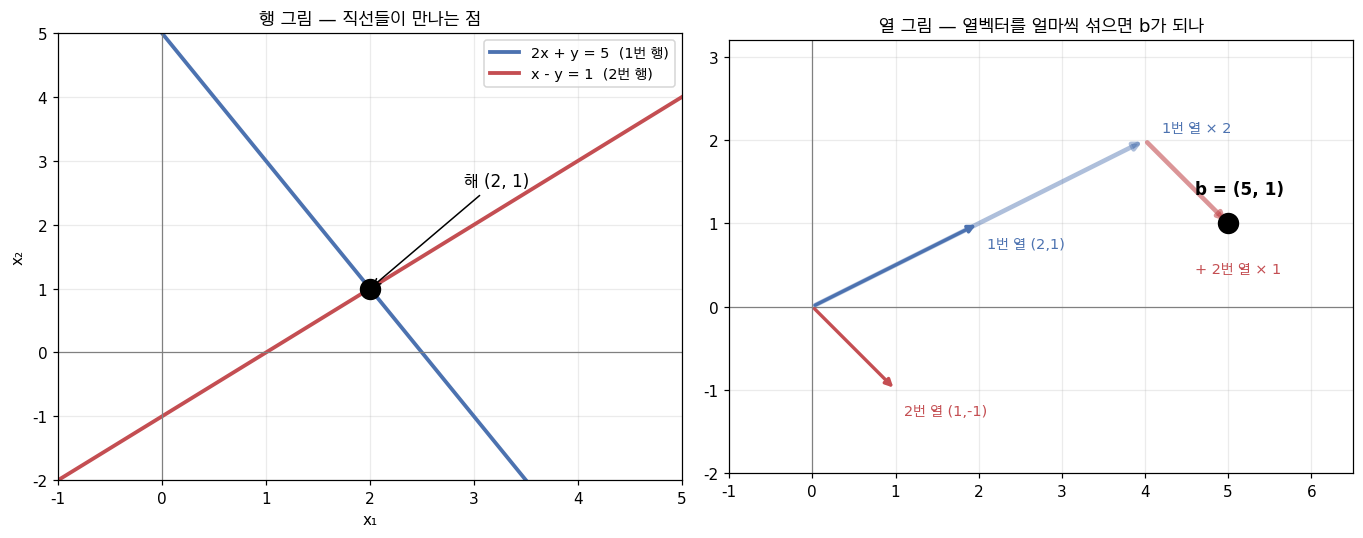

두 그림은 같은 답을 주지만, 왼쪽은 '2차원에서 두 선의 교점'이고
오른쪽은 '두 벡터의 합으로 b 만들기'입니다.
오른쪽 관점이 중요한 이유: 방정식이 100개여도 미지수가 2개면 여전히 벡터 2개의 조합 문제입니다.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))

# 행 그림
xs = np.linspace(-1, 5, 100)
ax1.plot(xs, 5 - 2 * xs, lw=2.5, color="#4c72b0", label="2x + y = 5  (1번 행)")
ax1.plot(xs, xs - 1, lw=2.5, color="#c44e52", label="x - y = 1  (2번 행)")
ax1.plot(*x, "o", ms=13, color="black", zorder=6)
ax1.annotate(f"해 ({x[0]:g}, {x[1]:g})", xy=x, xytext=(2.9, 2.6), fontsize=11,
             arrowprops=dict(arrowstyle="->", color="black"))
ax1.set_xlim(-1, 5); ax1.set_ylim(-2, 5)
ax1.axhline(0, color="gray", lw=0.8); ax1.axvline(0, color="gray", lw=0.8)
ax1.set_xlabel("x₁"); ax1.set_ylabel("x₂")
ax1.set_title("행 그림 — 직선들이 만나는 점", fontsize=12)
ax1.legend(fontsize=9.5); ax1.grid(alpha=0.25)

# 열 그림
col1, col2 = A[:, 0], A[:, 1]
ax2.annotate("", xy=col1, xytext=(0, 0),
             arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#4c72b0"))
ax2.annotate("", xy=x[0] * col1, xytext=(0, 0),
             arrowprops=dict(arrowstyle="-|>", lw=3, color="#4c72b0", alpha=0.45))
ax2.annotate("", xy=b, xytext=x[0] * col1,
             arrowprops=dict(arrowstyle="-|>", lw=3, color="#c44e52", alpha=0.6))
ax2.annotate("", xy=col2, xytext=(0, 0),
             arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#c44e52"))
ax2.plot(*b, "o", ms=13, color="black", zorder=6)
ax2.text(col1[0] + 0.1, col1[1] - 0.3, "1번 열 (2,1)", fontsize=9.5, color="#4c72b0")
ax2.text(col2[0] + 0.1, col2[1] - 0.3, "2번 열 (1,-1)", fontsize=9.5, color="#c44e52")
ax2.text(4.2, 2.1, f"1번 열 × {x[0]:g}", fontsize=9.5, color="#4c72b0")
ax2.text(4.6, 0.4, f"+ 2번 열 × {x[1]:g}", fontsize=9.5, color="#c44e52")
ax2.text(b[0] - 0.4, b[1] + 0.35, "b = (5, 1)", fontsize=11, weight="bold")
ax2.set_xlim(-1, 6.5); ax2.set_ylim(-2, 3.2)
ax2.axhline(0, color="gray", lw=0.8); ax2.axvline(0, color="gray", lw=0.8)
ax2.set_aspect("equal")
ax2.set_title("열 그림 — 열벡터를 얼마씩 섞으면 b가 되나", fontsize=12)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("두 그림은 같은 답을 주지만, 왼쪽은 '2차원에서 두 선의 교점'이고")
print("오른쪽은 '두 벡터의 합으로 b 만들기'입니다.")
print("오른쪽 관점이 중요한 이유: 방정식이 100개여도 미지수가 2개면 여전히 벡터 2개의 조합 문제입니다.")

## 2️⃣ 가우스 소거법 — 가장 직접적인 방법

가우스 소거법은 `Ax = b`를 **상삼각 시스템** `Ux = c`로 바꾼 뒤 뒤에서부터 풀어 나갑니다.

### 📐 알고리즘

```
1. 각 열 k(피벗 열)에 대해:
   a. k행 이하에서 k열의 절댓값이 가장 큰 원소를 찾는다  ← 부분 피벗팅(3절)
   b. 그 행을 k행과 맞바꾼다
   c. k행 아래의 각 행 i에 대해:
      - 승수 m = A[i][k] / A[k][k]
      - i행에서 (m × k행)을 뺀다
2. 후진 대입: 마지막 방정식부터 위로 올라가며 푼다
```

### 📐 손으로 따라가 보기

```
원본:
| 2  1  1 |  8 |      R2 ← R2 - 2·R1     | 2  1   1 |  8 |
| 4  3  3 | 20 |  →   R3 ← R3 - 1·R1  →  | 0  1   1 |  4 |
| 2  3  1 | 12 |                          | 0  2   0 |  4 |

                      R3 ← R3 - 2·R2      | 2  1   1 |  8 |
                                      →   | 0  1   1 |  4 |
                                          | 0  0  -2 | -4 |
후진 대입:
  -2·x₃ = -4        →  x₃ = 2
  x₂ + 2 = 4        →  x₂ = 2
  2·x₁ + 2 + 2 = 8  →  x₁ = 2
```

### ⚠️ 비용

가우스 소거법은 **O(n³)** 연산이 듭니다. 1000×1000 시스템이면 약 10억 번의 부동소수점 연산이에요.
빠른 편이지만, **같은 `A`로 여러 개의 `b`를 풀어야 한다면 더 잘할 수 있습니다.** 그게 4절의 LU 분해입니다.

In [5]:
def gaussian_elimination(A, b, verbose=False):
    n = len(b)
    Ab = np.hstack([np.asarray(A, dtype=float), np.asarray(b, dtype=float).reshape(-1, 1)])

    for k in range(n):
        # 부분 피벗팅: k열에서 절댓값이 가장 큰 행을 위로 올립니다
        max_row = k + int(np.argmax(np.abs(Ab[k:, k])))
        if max_row != k:
            Ab[[k, max_row]] = Ab[[max_row, k]]
            if verbose:
                print(f"  [피벗] {k}행 ↔ {max_row}행 교환")
        if abs(Ab[k, k]) < 1e-12:
            raise ValueError(f"{k}번 피벗에서 특이(singular) 행렬입니다")

        for i in range(k + 1, n):
            m = Ab[i, k] / Ab[k, k]
            Ab[i, k:] -= m * Ab[k, k:]
        if verbose:
            print(f"  [{k}열 소거 후]\n{Ab}\n")

    # 후진 대입
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Ab[i, -1] - Ab[i, i + 1:n] @ x[i + 1:n]) / Ab[i, i]
    return x

A = np.array([[2.0, 1, 1],
              [4, 3, 3],
              [2, 3, 1]])
b = np.array([8.0, 20, 12])

print("소거 과정을 따라가 봅니다 (부분 피벗팅 포함이라 손 계산과 순서가 다릅니다)")
x = gaussian_elimination(A, b, verbose=True)
print(f"해      : {x}")
print(f"NumPy   : {np.linalg.solve(A, b)}")
print(f"검증 Ax : {A @ x}   (b = {b})")
print(f"잔차    : {np.linalg.norm(A @ x - b):.2e}")

소거 과정을 따라가 봅니다 (부분 피벗팅 포함이라 손 계산과 순서가 다릅니다)
  [피벗] 0행 ↔ 1행 교환
  [0열 소거 후]
[[ 4.   3.   3.  20. ]
 [ 0.  -0.5 -0.5 -2. ]
 [ 0.   1.5 -0.5  2. ]]

  [피벗] 1행 ↔ 2행 교환
  [1열 소거 후]
[[ 4.       3.       3.      20.     ]
 [ 0.       1.5     -0.5      2.     ]
 [ 0.       0.      -0.66667 -1.33333]]

  [2열 소거 후]
[[ 4.       3.       3.      20.     ]
 [ 0.       1.5     -0.5      2.     ]
 [ 0.       0.      -0.66667 -1.33333]]

해      : [2. 2. 2.]
NumPy   : [2. 2. 2.]
검증 Ax : [ 8. 20. 12.]   (b = [ 8. 20. 12.])
잔차    : 0.00e+00


## 3️⃣ 부분 피벗팅 — 왜 순서를 바꾸는 것만으로 답이 달라지나

여기가 5주차 수치안정성과 직접 이어지는 지점입니다.

피벗팅 없이 가우스 소거를 하면 **실패하거나 쓰레기 값을 내놓을 수 있습니다.**
피벗 원소가 0이면 0으로 나누게 되고, **0이 아니라도 아주 작으면 반올림 오차가 증폭됩니다.**

```
피벗팅 없음:                       부분 피벗팅:
| 0.001  1 | 1.001 |              먼저 행을 바꾸고 시작:
| 1      1 | 2     |              | 1      1 | 2     |
                                   | 0.001  1 | 1.001 |
m = 1/0.001 = 1000                m = 0.001/1 = 0.001
       ↑ 1000배 증폭!                     ↑ 승수가 작다 = 안전
```

**핵심은 승수 `m`의 크기입니다.**
`m`이 크면 원래 행의 반올림 오차가 그만큼 곱해져서 퍼집니다.
부분 피벗팅은 **항상 가장 큰 피벗을 고르므로 `|m| ≤ 1`을 보장**합니다. 그래서 오차가 증폭되지 않습니다.

> 💡 5주차에서 "거의 같은 두 수를 빼면 유효숫자가 날아간다(파괴적 상쇄)"를 배웠는데,
> 여기서는 그 상쇄가 **큰 승수 때문에** 발생합니다. 같은 병의 다른 증상입니다.

In [6]:
def gaussian_no_pivot(A, b):
    # 일부러 피벗팅을 뺀 버전 — 비교용입니다
    n = len(b)
    Ab = np.hstack([np.asarray(A, dtype=float), np.asarray(b, dtype=float).reshape(-1, 1)])
    for k in range(n):
        if Ab[k, k] == 0:
            raise ValueError("피벗이 0입니다")
        for i in range(k + 1, n):
            m = Ab[i, k] / Ab[k, k]
            Ab[i, k:] -= m * Ab[k, k:]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Ab[i, -1] - Ab[i, i + 1:n] @ x[i + 1:n]) / Ab[i, i]
    return x

print("작은 피벗이 얼마나 위험한지 — 정답은 항상 x = [1, 1] 입니다\n")
print(f"{'ε':>10}{'피벗팅 없음':>28}{'부분 피벗팅':>28}")
print("-" * 68)
for eps in [1e-1, 1e-4, 1e-8, 1e-12, 1e-16, 1e-18]:
    A_bad = np.array([[eps, 1.0], [1.0, 1.0]])
    b_bad = np.array([1.0 + eps, 2.0])          # 정확한 해는 [1, 1]
    x_no = gaussian_no_pivot(A_bad, b_bad)
    x_pp = gaussian_elimination(A_bad, b_bad)
    print(f"{eps:>10.0e}{str(np.round(x_no, 6)):>28}{str(np.round(x_pp, 6)):>28}")

print("\n=> ε이 작아질수록 왼쪽은 무너지고, 오른쪽은 끝까지 버팁니다.")
print("   행 순서만 바꿨을 뿐인데 답이 살아납니다. 이게 부분 피벗팅입니다.")

print("\n[승수의 크기를 직접 봅시다]")
eps = 1e-12
print(f"  피벗팅 없음: m = 1 / {eps:.0e} = {1/eps:.0e}   <- 이만큼 오차가 증폭됩니다")
print(f"  부분 피벗팅: m = {eps:.0e} / 1 = {eps:.0e}   <- 오히려 축소됩니다")
print("  부분 피벗팅은 항상 |m| ≤ 1 을 보장합니다.")

작은 피벗이 얼마나 위험한지 — 정답은 항상 x = [1, 1] 입니다

         ε                      피벗팅 없음                      부분 피벗팅
--------------------------------------------------------------------
     1e-01                     [1. 1.]                     [1. 1.]
     1e-04                     [1. 1.]                     [1. 1.]
     1e-08                     [1. 1.]                     [1. 1.]
     1e-12           [0.99987 1.     ]                     [1. 1.]
     1e-16           [2.22045 1.     ]                     [1. 1.]
     1e-18                     [0. 1.]                     [1. 1.]

=> ε이 작아질수록 왼쪽은 무너지고, 오른쪽은 끝까지 버팁니다.
   행 순서만 바꿨을 뿐인데 답이 살아납니다. 이게 부분 피벗팅입니다.

[승수의 크기를 직접 봅시다]
  피벗팅 없음: m = 1 / 1e-12 = 1e+12   <- 이만큼 오차가 증폭됩니다
  부분 피벗팅: m = 1e-12 / 1 = 1e-12   <- 오히려 축소됩니다
  부분 피벗팅은 항상 |m| ≤ 1 을 보장합니다.


### 🖼️ 그림 2 — 피벗팅이 만드는 차이

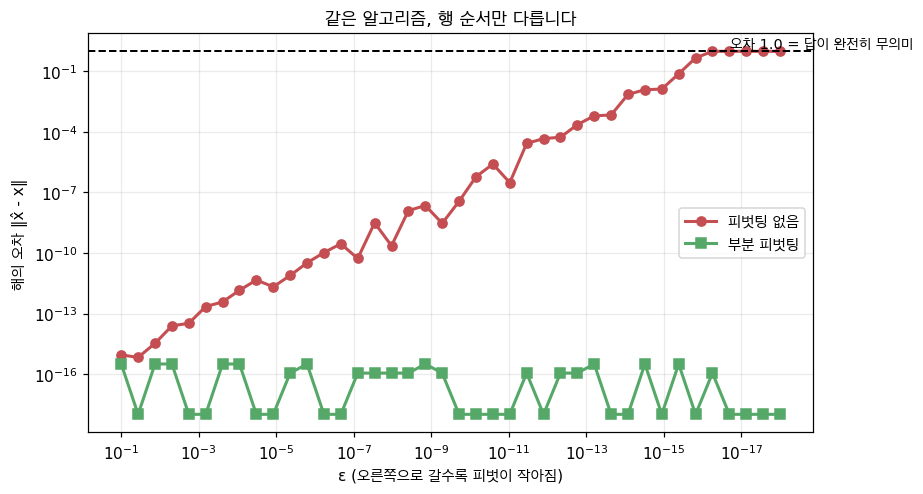

ε = 1e-18 에서의 오차:  피벗팅 없음 1.0000   부분 피벗팅 0.00e+00

💡 LAPACK을 비롯한 모든 실전 선형대수 라이브러리는 기본으로 부분 피벗팅을 씁니다.
   np.linalg.solve 도 내부에서 이걸 하고 있습니다.


In [7]:
epss = np.logspace(-1, -18, 40)
err_no, err_pp = [], []
for eps in epss:
    A_bad = np.array([[eps, 1.0], [1.0, 1.0]])
    b_bad = np.array([1.0 + eps, 2.0])
    true = np.array([1.0, 1.0])
    err_no.append(np.linalg.norm(gaussian_no_pivot(A_bad, b_bad) - true))
    err_pp.append(np.linalg.norm(gaussian_elimination(A_bad, b_bad) - true))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.loglog(epss, np.maximum(err_no, 1e-18), "o-", color="#c44e52", lw=2,
          label="피벗팅 없음")
ax.loglog(epss, np.maximum(err_pp, 1e-18), "s-", color="#55a868", lw=2,
          label="부분 피벗팅")
ax.axhline(1.0, color="black", ls="--", lw=1.3)
ax.text(2e-17, 1.4, "오차 1.0 = 답이 완전히 무의미", fontsize=9.5)
ax.invert_xaxis()
ax.set_xlabel("ε (오른쪽으로 갈수록 피벗이 작아짐)")
ax.set_ylabel("해의 오차 ‖x̂ - x‖")
ax.set_title("같은 알고리즘, 행 순서만 다릅니다", fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.show()

print(f"ε = 1e-18 에서의 오차:  피벗팅 없음 {err_no[-1]:.4f}   부분 피벗팅 {err_pp[-1]:.2e}")
print("\n💡 LAPACK을 비롯한 모든 실전 선형대수 라이브러리는 기본으로 부분 피벗팅을 씁니다.")
print("   np.linalg.solve 도 내부에서 이걸 하고 있습니다.")

## 4️⃣ LU 분해 — 한 번 일하고 여러 번 우려먹기

### 🧸 비유 — 요리 재료 손질

같은 재료로 요리를 100번 한다고 생각해 보세요.
매번 처음부터 채소를 씻고 썰면 100번의 손질이 필요합니다.
**한 번에 다 손질해서 보관해 두면**, 이후로는 볶기만 하면 됩니다.

LU 분해가 정확히 이겁니다. `A`를 **한 번만** 손질해 두고, `b`가 바뀔 때마다 싸게 풀어냅니다.

### 📐 개념

`A`를 하삼각 행렬 `L`과 상삼각 행렬 `U`의 곱으로 쪼갭니다.

$$A = LU$$

`L`에는 가우스 소거의 **승수**들이 저장되고, `U`는 **소거가 끝난 결과**입니다.

```
| 2  1  1 |   | 1  0  0 |   | 2  1   1 |
| 4  3  3 | = | 2  1  0 | @ | 0  1   1 |
| 2  3  1 |   | 1  2  1 |   | 0  0  -2 |
```

### 🔑 왜 굳이 분해하나

한 번 `L`과 `U`를 갖고 있으면, **새로운 `b`에 대한 풀이가 O(n²)** 로 끝납니다.

```
Ax = b
LUx = b
y = Ux 라고 두면:
  Ly = b   (전진 대입, O(n²))
  Ux = y   (후진 대입, O(n²))
```

O(n³) 비용은 **분해할 때 딱 한 번** 냅니다. 이후의 모든 풀이는 O(n²)예요.
`b`가 1000개라면 총 작업량이 **수백 배** 줄어듭니다.

부분 피벗팅을 넣으면 `PA = LU` 형태가 되는데, `P`는 행 교환을 기록한 순열 행렬입니다.

In [8]:
def lu_decompose(A):
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy()
    P = np.eye(n)

    for k in range(n):
        max_row = k + int(np.argmax(np.abs(U[k:, k])))
        if max_row != k:
            U[[k, max_row]] = U[[max_row, k]]
            P[[k, max_row]] = P[[max_row, k]]
            if k > 0:
                L[[k, max_row], :k] = L[[max_row, k], :k]   # 이미 저장된 승수도 함께 교환
        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
    return P, L, U

def lu_solve(P, L, U, b):
    b = np.asarray(b, dtype=float)
    n = len(b)
    Pb = P @ b
    y = np.zeros(n)
    for i in range(n):                       # 전진 대입 Ly = Pb
        y[i] = Pb[i] - L[i, :i] @ y[:i]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):           # 후진 대입 Ux = y
        x[i] = (y[i] - U[i, i + 1:] @ x[i + 1:]) / U[i, i]
    return x

A = np.array([[2.0, 1, 1], [4, 3, 3], [2, 3, 1]])
P, L, U = lu_decompose(A)
print("L =\n", L)
print("U =\n", U)
print("P =\n", P)
print(f"\n검증 PA = LU ?  최대 오차 {np.abs(P @ A - L @ U).max():.2e}")
print(f"L은 하삼각인가? {np.allclose(L, np.tril(L))}")
print(f"U는 상삼각인가? {np.allclose(U, np.triu(U))}")

print("\n같은 A, 서로 다른 b 세 개를 풀어 봅니다 (분해는 한 번만)")
for b in [np.array([8.0, 20, 12]), np.array([1.0, 0, 0]), np.array([3.0, -1, 7])]:
    x = lu_solve(P, L, U, b)
    print(f"  b = {b}  ->  x = {np.round(x, 6)}   잔차 {np.linalg.norm(A@x-b):.2e}")

L =
 [[ 1.       0.       0.     ]
 [ 0.5      1.       0.     ]
 [ 0.5     -0.33333  1.     ]]
U =
 [[ 4.       3.       3.     ]
 [ 0.       1.5     -0.5    ]
 [ 0.       0.      -0.66667]]
P =
 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]

검증 PA = LU ?  최대 오차 0.00e+00
L은 하삼각인가? True
U는 상삼각인가? True

같은 A, 서로 다른 b 세 개를 풀어 봅니다 (분해는 한 번만)
  b = [ 8. 20. 12.]  ->  x = [2. 2. 2.]   잔차 8.88e-16
  b = [1. 0. 0.]  ->  x = [ 1.5 -0.5 -1.5]   잔차 0.00e+00
  b = [ 3. -1.  7.]  ->  x = [ 5.  2. -9.]   잔차 0.00e+00


### 🖼️ 그림 3 — 분해가 언제부터 이득인가

행렬 크기 220×220
  LU 분해 1회      :    34.05 ms   (O(n³), 한 번만)
  LU 풀이 1회      :     0.42 ms   (O(n²), 매번)
  가우스 소거 1회  :    38.79 ms   (O(n³), 매번)
  분해 대비 풀이가 81배 쌉니다


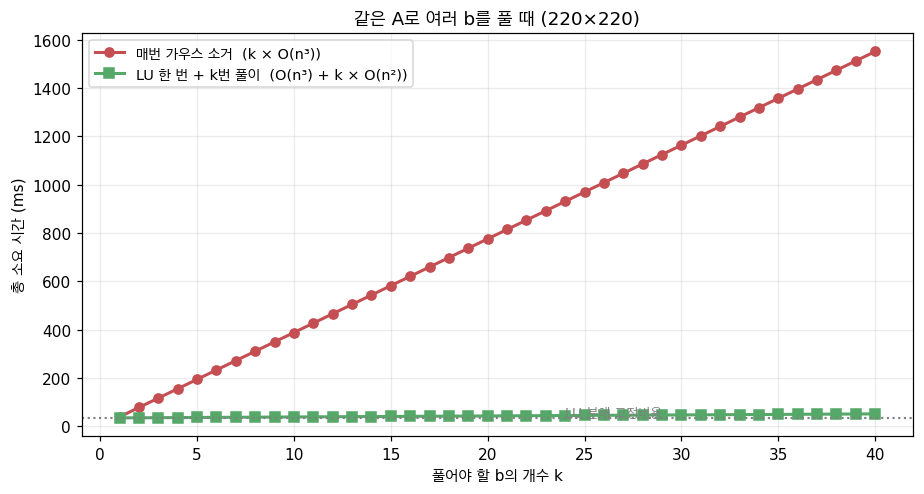


b가 40개일 때: 가우스 1552ms  vs  LU 51ms (30.5배 빠름)
💡 실무에서 이런 상황: 같은 커널 행렬로 여러 타깃을 예측(GP), 뉴턴법 반복, 시뮬레이션 시간 스텝.


In [9]:
def time_it(fn, repeats=3):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - t0)
    return best

rng = np.random.default_rng(1)
N = 220
A_big = rng.normal(size=(N, N)) + N * np.eye(N)      # 잘 조건화된 행렬
bs = [rng.normal(size=N) for _ in range(40)]

t_factor = time_it(lambda: lu_decompose(A_big))
P_big, L_big, U_big = lu_decompose(A_big)
t_solve = time_it(lambda: lu_solve(P_big, L_big, U_big, bs[0]))
t_gauss = time_it(lambda: gaussian_elimination(A_big, bs[0]))

print(f"행렬 크기 {N}×{N}")
print(f"  LU 분해 1회      : {t_factor*1000:8.2f} ms   (O(n³), 한 번만)")
print(f"  LU 풀이 1회      : {t_solve*1000:8.2f} ms   (O(n²), 매번)")
print(f"  가우스 소거 1회  : {t_gauss*1000:8.2f} ms   (O(n³), 매번)")
print(f"  분해 대비 풀이가 {t_factor/t_solve:.0f}배 쌉니다")

ks = np.arange(1, 41)
cost_gauss = ks * t_gauss
cost_lu = t_factor + ks * t_solve

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(ks, cost_gauss * 1000, "o-", color="#c44e52", lw=2,
        label="매번 가우스 소거  (k × O(n³))")
ax.plot(ks, cost_lu * 1000, "s-", color="#55a868", lw=2,
        label="LU 한 번 + k번 풀이  (O(n³) + k × O(n²))")
ax.axhline(t_factor * 1000, color="gray", ls=":", lw=1.4)
ax.text(24, t_factor * 1000 * 1.08, "LU 분해 고정비용", fontsize=9, color="gray")
ax.set_xlabel("풀어야 할 b의 개수 k"); ax.set_ylabel("총 소요 시간 (ms)")
ax.set_title(f"같은 A로 여러 b를 풀 때 ({N}×{N})", fontsize=12)
ax.legend(fontsize=9.5); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"\nb가 40개일 때: 가우스 {cost_gauss[-1]*1000:.0f}ms  vs  LU {cost_lu[-1]*1000:.0f}ms "
      f"({cost_gauss[-1]/cost_lu[-1]:.1f}배 빠름)")
print("💡 실무에서 이런 상황: 같은 커널 행렬로 여러 타깃을 예측(GP), 뉴턴법 반복, 시뮬레이션 시간 스텝.")

## 5️⃣ QR 분해 — 직교화로 얻는 안정성

`A`를 **직교 행렬** `Q`와 상삼각 행렬 `R`의 곱으로 쪼갭니다.

$$A = QR, \qquad Q^\top Q = I$$

직교 행렬은 **길이와 각도를 보존**합니다. 회전·반사만 할 뿐 늘이거나 줄이지 않아요.
그래서 **오차를 증폭시키지 않습니다.** 이게 QR이 수치적으로 안정적인 이유입니다.

풀이는 아주 깔끔합니다. **역행렬을 구할 필요조차 없습니다.**

```
QRx = b
Rx = Qᵀb      ← Q의 역행렬이 곧 Qᵀ 입니다
후진 대입으로 x를 얻습니다
```

### 📐 그람-슈미트 과정 — `Q`를 한 열씩 쌓기

발상은 단순합니다. **이미 만든 방향들의 성분을 빼면, 남는 건 새로운 직교 방향입니다.**

```
q₁ = a₁ / ‖a₁‖

q₂ = a₂ - (a₂·q₁)q₁       ← q₁ 방향 성분을 제거
q₂ = q₂ / ‖q₂‖            ← 정규화

q₃ = a₃ - (a₃·q₁)q₁ - (a₃·q₂)q₂
q₃ = q₃ / ‖q₃‖
```

### ⚠️ 그런데 여기에 함정이 있습니다

위 방식(**고전 그람-슈미트**)은 **수치적으로 불안정합니다.**
빼는 과정에서 반올림 오차가 쌓여, 만들어진 `Q`의 열들이 서로 직교하지 않게 됩니다.

**수정 그람-슈미트(Modified Gram-Schmidt)** 는 순서만 살짝 바꿉니다.
"모든 투영을 한꺼번에 빼기" 대신 **"하나 빼고 갱신, 또 하나 빼고 갱신"** 을 합니다.
수학적으로는 완전히 같은데, 부동소수점에서는 결과가 크게 다릅니다.
아래에서 직접 확인해 보겠습니다. **5주차의 교훈이 또 나오는 셈입니다.**

In [10]:
def gram_schmidt_classical(A):
    A = np.asarray(A, dtype=float)
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            R[i, j] = Q[:, i] @ A[:, j]     # ← 원본 A의 열로 한꺼번에 투영을 계산
            v -= R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    return Q, R

def gram_schmidt_modified(A):
    A = np.asarray(A, dtype=float)
    m, n = A.shape
    Q = np.zeros((m, n))
    V = A.copy()
    R = np.zeros((n, n))
    for j in range(n):
        R[j, j] = np.linalg.norm(V[:, j])
        Q[:, j] = V[:, j] / R[j, j]
        for k in range(j + 1, n):
            R[j, k] = Q[:, j] @ V[:, k]     # ← 매번 '갱신된' V로 투영을 계산
            V[:, k] -= R[j, k] * Q[:, j]
    return Q, R

A_test = np.array([[1.0, 1, 0], [1, 0, 1], [0, 1, 1], [1, 1, 1]])
Q, R = gram_schmidt_modified(A_test)
print("Q =\n", np.round(Q, 5))
print("\nR =\n", np.round(R, 5))
print(f"\nQᵀQ = I 인가?  최대 오차 {np.abs(Q.T @ Q - np.eye(3)).max():.2e}")
print(f"A = QR 인가?   최대 오차 {np.abs(Q @ R - A_test).max():.2e}")
print(f"R은 상삼각인가? {np.allclose(R, np.triu(R))}")

print("\n[⚠️ 고전 vs 수정 그람-슈미트 — 조건이 나쁜 행렬에서]")
print(f"{'조건수':>12}{'고전 GS의 직교성 오차':>26}{'수정 GS의 직교성 오차':>26}")
print("-" * 66)
rng = np.random.default_rng(3)
for exp in [2, 5, 8, 11]:
    # 특이값을 일부러 넓게 퍼뜨려 조건이 나쁜 행렬을 만듭니다
    n = 8
    U_, _ = np.linalg.qr(rng.normal(size=(n, n)))
    V_, _ = np.linalg.qr(rng.normal(size=(n, n)))
    s = np.logspace(0, -exp, n)
    M = U_ @ np.diag(s) @ V_.T
    Qc, _ = gram_schmidt_classical(M)
    Qm, _ = gram_schmidt_modified(M)
    ec = np.abs(Qc.T @ Qc - np.eye(n)).max()
    em = np.abs(Qm.T @ Qm - np.eye(n)).max()
    print(f"{np.linalg.cond(M):>12.1e}{ec:>26.2e}{em:>26.2e}")

print("\n=> 수학적으로 동일한 두 알고리즘인데 오차가 몇 자릿수씩 차이 납니다.")
print("   '식이 같으니 코드도 같겠지'가 부동소수점에서는 성립하지 않습니다 (5주차의 교훈).")
print("   참고로 LAPACK은 둘 다 안 쓰고 하우스홀더 반사를 씁니다. 그게 더 안정적입니다.")

Q =
 [[ 0.57735  0.2582  -0.67612]
 [ 0.57735 -0.5164   0.50709]
 [ 0.       0.7746   0.50709]
 [ 0.57735  0.2582   0.16903]]

R =
 [[1.73205 1.1547  1.1547 ]
 [0.      1.29099 0.5164 ]
 [0.      0.      1.18322]]

QᵀQ = I 인가?  최대 오차 2.60e-16
A = QR 인가?   최대 오차 3.32e-17
R은 상삼각인가? True

[⚠️ 고전 vs 수정 그람-슈미트 — 조건이 나쁜 행렬에서]
         조건수             고전 GS의 직교성 오차             수정 GS의 직교성 오차
------------------------------------------------------------------
     1.0e+02                  6.26e-14                  2.42e-15
     1.0e+05                  4.36e-09                  1.77e-12
     1.0e+08                  4.36e-03                  4.07e-09
     1.0e+11                  1.00e+00                  6.45e-07

=> 수학적으로 동일한 두 알고리즘인데 오차가 몇 자릿수씩 차이 납니다.
   '식이 같으니 코드도 같겠지'가 부동소수점에서는 성립하지 않습니다 (5주차의 교훈).
   참고로 LAPACK은 둘 다 안 쓰고 하우스홀더 반사를 씁니다. 그게 더 안정적입니다.


## 6️⃣ 촐레스키 분해 — 대칭 양정부호 전용 특급 열차

`A`가 **대칭**(`A = Aᵀ`)이고 **양정부호**(모든 고유값 > 0)라면, 더 좋은 방법이 있습니다.

$$A = LL^\top$$

`L`은 하삼각 행렬 하나뿐입니다. 이름 그대로 **"행렬의 제곱근"** 같은 존재예요.

```
| 4  2 |   | 2  0 |   | 2  1 |
| 2  5 | = | 1  2 | @ | 0  2 |
```

### 🔑 왜 좋은가

- **LU보다 2배 빠릅니다** (O(n³/3))
- **저장 공간도 절반**입니다 (삼각 행렬 하나만)
- 분해가 **실패하면** 그 자체로 "양정부호가 아니다"라는 진단이 됩니다

### 🏭 그런데 이 조건이 ML에서 계속 나옵니다

조건이 까다로워 보이지만, 실제로는 **대칭 양정부호 행렬을 아주 자주 만납니다.**

- **공분산 행렬**은 항상 대칭 양반정부호입니다 (정규화를 더하면 양정부호)
- **가우시안 프로세스의 커널 행렬**이 대칭 양정부호입니다
- **볼록 함수의 헤시안**이 최솟값에서 대칭 양정부호입니다 (다음 노트북의 주제)
- **`AᵀA`는 언제나** 대칭 양반정부호입니다 ← 정규방정식이 여기 해당합니다

가우시안 프로세스에서는 커널 행렬 `K`를 촐레스키로 분해한 뒤 `Kα = y`를 풀어 예측 평균을 얻습니다.
그리고 주변 우도에 필요한 로그 행렬식도 공짜로 나옵니다.

$$\log \det(K) = 2\sum_i \log L_{ii}$$

행렬식을 직접 계산하면 오버플로가 나기 십상인데, 이 방법은 **로그 공간에서 안전하게** 구합니다.
5주차에서 배운 "로그 공간에서 계산하라"가 여기서도 적용됩니다.

In [11]:
def cholesky(A):
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    L = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1):
            s = A[i, j] - L[i, :j] @ L[j, :j]
            if i == j:
                if s <= 0:
                    raise ValueError("양정부호 행렬이 아닙니다 (대각 원소가 음수/0)")
                L[i, j] = math.sqrt(s)
            else:
                L[i, j] = s / L[j, j]
    return L

def cholesky_solve(L, b):
    n = len(b)
    y = np.zeros(n)
    for i in range(n):                       # Ly = b
        y[i] = (b[i] - L[i, :i] @ y[:i]) / L[i, i]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):           # Lᵀx = y
        x[i] = (y[i] - L[i + 1:, i] @ x[i + 1:]) / L[i, i]
    return x

A_spd = np.array([[4.0, 2], [2, 5]])
L = cholesky(A_spd)
print("A =\n", A_spd)
print("L =\n", L)
print(f"LLᵀ 검증: 최대 오차 {np.abs(L @ L.T - A_spd).max():.2e}")
print(f"NumPy 대조: 최대 오차 {np.abs(L - np.linalg.cholesky(A_spd)).max():.2e}")

print("\n[양정부호가 아니면 알아서 실패합니다 — 이게 진단 도구가 됩니다]")
A_not_pd = np.array([[1.0, 2], [2, 1]])       # 고유값 3, -1
print(f"  고유값: {np.linalg.eigvalsh(A_not_pd)}")
try:
    cholesky(A_not_pd)
except ValueError as e:
    print(f"  촐레스키 결과: {e}")

print("\n[🏭 로그 행렬식 — GP 주변우도에 필요합니다]")
rng = np.random.default_rng(5)
n = 60
Z = rng.normal(size=(n, n))
K = Z @ Z.T / n + 0.1 * np.eye(n)            # 대칭 양정부호 커널 행렬 흉내
L_k = cholesky(K)
logdet_chol = 2 * np.sum(np.log(np.diag(L_k)))
sign, logdet_np = np.linalg.slogdet(K)
print(f"  촐레스키 방식 2·Σlog(Lᵢᵢ) = {logdet_chol:.8f}")
print(f"  np.linalg.slogdet          = {logdet_np:.8f}")
print(f"  참고로 det(K) 자체         = {np.linalg.det(K):.4e}  <- 크기가 크면 여기서 오버플로/언더플로")

A =
 [[4. 2.]
 [2. 5.]]
L =
 [[2. 0.]
 [1. 2.]]
LLᵀ 검증: 최대 오차 0.00e+00
NumPy 대조: 최대 오차 0.00e+00

[양정부호가 아니면 알아서 실패합니다 — 이게 진단 도구가 됩니다]
  고유값: [-1.  3.]
  촐레스키 결과: 양정부호 행렬이 아닙니다 (대각 원소가 음수/0)

[🏭 로그 행렬식 — GP 주변우도에 필요합니다]
  촐레스키 방식 2·Σlog(Lᵢᵢ) = -25.38789670
  np.linalg.slogdet          = -25.38789670
  참고로 det(K) 자체         = 9.4227e-12  <- 크기가 크면 여기서 오버플로/언더플로


### 🖼️ 그림 4 — 세 분해의 속도 비교

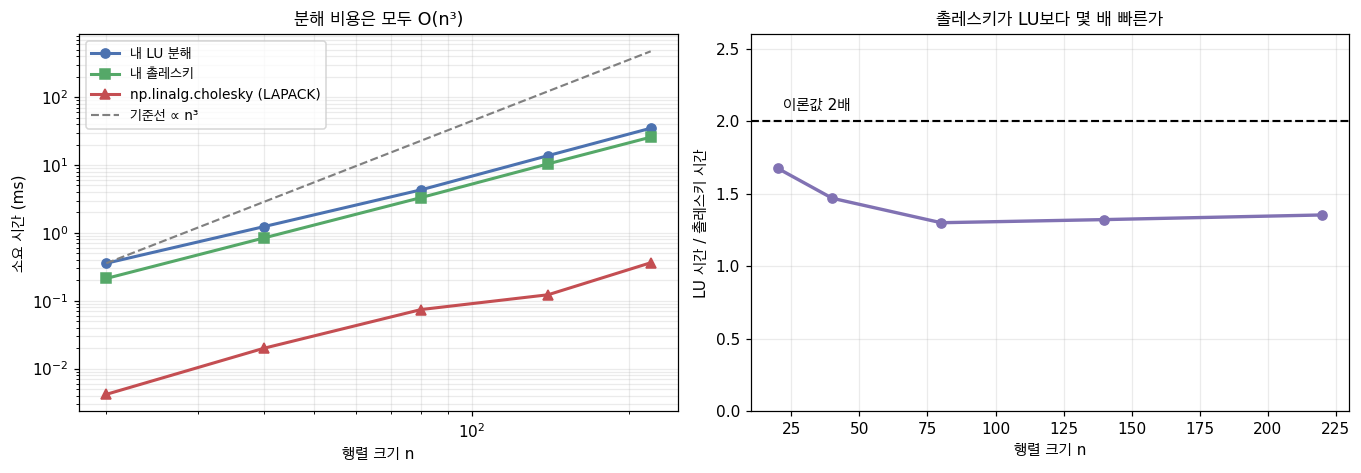

n=220에서 LU/촐레스키 비율 = 1.35배 (이론값 2배)
LAPACK은 같은 촐레스키인데도 내 구현보다 71배 빠릅니다.
  이유: 캐시 친화적 블록 알고리즘 + SIMD + 멀티스레딩. 알고리즘이 아니라 구현의 차이입니다.
  => 원리는 직접 구현해서 이해하고, 실전에서는 LAPACK 기반 라이브러리를 쓰세요.


In [12]:
sizes = [20, 40, 80, 140, 220]
t_lu, t_chol, t_np = [], [], []
rng = np.random.default_rng(7)
for n in sizes:
    Z = rng.normal(size=(n, n))
    S = Z @ Z.T + n * np.eye(n)              # 대칭 양정부호
    t_lu.append(time_it(lambda S=S: lu_decompose(S)))
    t_chol.append(time_it(lambda S=S: cholesky(S)))
    t_np.append(time_it(lambda S=S: np.linalg.cholesky(S)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax1.loglog(sizes, np.array(t_lu) * 1000, "o-", color="#4c72b0", lw=2, label="내 LU 분해")
ax1.loglog(sizes, np.array(t_chol) * 1000, "s-", color="#55a868", lw=2, label="내 촐레스키")
ax1.loglog(sizes, np.array(t_np) * 1000, "^-", color="#c44e52", lw=2,
           label="np.linalg.cholesky (LAPACK)")
ref = np.array(sizes, dtype=float) ** 3
ax1.loglog(sizes, ref / ref[0] * t_lu[0] * 1000, "--", color="gray", lw=1.4, label="기준선 ∝ n³")
ax1.set_xlabel("행렬 크기 n"); ax1.set_ylabel("소요 시간 (ms)")
ax1.set_title("분해 비용은 모두 O(n³)", fontsize=11.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.25, which="both")

ratio = np.array(t_lu) / np.array(t_chol)
ax2.plot(sizes, ratio, "o-", color="#8172b3", lw=2.2)
ax2.axhline(2.0, color="black", ls="--", lw=1.4)
ax2.text(sizes[0] * 1.1, 2.08, "이론값 2배", fontsize=10)
ax2.set_xlabel("행렬 크기 n"); ax2.set_ylabel("LU 시간 / 촐레스키 시간")
ax2.set_ylim(0, max(ratio.max() * 1.2, 2.6))
ax2.set_title("촐레스키가 LU보다 몇 배 빠른가", fontsize=11.5)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"n={sizes[-1]}에서 LU/촐레스키 비율 = {ratio[-1]:.2f}배 (이론값 2배)")
print(f"LAPACK은 같은 촐레스키인데도 내 구현보다 {t_chol[-1]/t_np[-1]:.0f}배 빠릅니다.")
print("  이유: 캐시 친화적 블록 알고리즘 + SIMD + 멀티스레딩. 알고리즘이 아니라 구현의 차이입니다.")
print("  => 원리는 직접 구현해서 이해하고, 실전에서는 LAPACK 기반 라이브러리를 쓰세요.")

## 7️⃣ 최소제곱 — 답이 없을 때 가장 가까운 답 찾기

이제 ML에서 실제로 마주치는 상황입니다.

`A`가 `m × n`이고 **`m > n`**(방정식이 미지수보다 많음)이면 **과결정 시스템**입니다.
정확한 해는 **없습니다.** 대신 오차의 제곱합을 최소화합니다.

$$\min_x \lVert Ax - b \rVert^2$$

### 📐 정규방정식 유도 — 한 줄입니다

$$\lVert Ax-b \rVert^2 = (Ax-b)^\top(Ax-b) = x^\top A^\top A x - 2x^\top A^\top b + b^\top b$$

`x`에 대해 미분해서 0으로 두면:

$$2A^\top A x - 2A^\top b = 0 \quad\Longrightarrow\quad \boxed{A^\top A\,x = A^\top b}$$

이게 **정규방정식**입니다.

### 🔑 기하학적으로는 무슨 일이 벌어지나

1절의 열 그림을 떠올려 보세요. `Ax`는 열공간 안의 점만 만들 수 있습니다.
`b`가 열공간 밖에 있으면, 우리가 할 수 있는 최선은 **`b`를 열공간에 수직으로 투영**하는 것입니다.

그리고 "수직"이라는 조건이 정확히 정규방정식입니다.
잔차 `b − Ax`가 열공간의 **모든** 열과 수직이어야 하니까:

$$A^\top(b - Ax) = 0 \quad\Longrightarrow\quad A^\top A x = A^\top b$$

**미분으로 유도하든 기하로 유도하든 같은 식이 나옵니다.**

```
과결정 예 (방정식 4개, 미지수 2개):
| 1  1 |       | 3 |
| 1  2 | x  =  | 5 |     정확히 만족하는 x는 없습니다
| 1  3 |       | 6 |
| 1  4 |       | 8 |

정규방정식:
AᵀA = | 4  10 |    Aᵀb = | 22 |
      | 10 30 |          | 63 |

해: x = [1.5, 1.6]   ← 절편 1.5, 기울기 1.6. 이게 선형회귀입니다.
```

> 📌 **원문 정오표:** 영어 원문은 이 해를 `[1.5, 1.7]`로 적어 두었는데 **계산이 틀렸습니다.**
> `[1.5, 1.7]`의 잔차 제곱합은 0.5이고, 올바른 해 `[1.5, 1.6]`은 0.2입니다.
> 아래 코드에서 직접 확인합니다.

In [13]:
def least_squares_normal(A, b):
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    return gaussian_elimination(A.T @ A, A.T @ b)

A_over = np.array([[1.0, 1], [1, 2], [1, 3], [1, 4]])
b_over = np.array([3.0, 5, 6, 8])

x_ls = least_squares_normal(A_over, b_over)
print(f"AᵀA =\n{A_over.T @ A_over}")
print(f"Aᵀb = {A_over.T @ b_over}")
print(f"\n최소제곱 해 x = {x_ls}   (절편 {x_ls[0]:.2f}, 기울기 {x_ls[1]:.2f})")
print(f"np.linalg.lstsq: {np.linalg.lstsq(A_over, b_over, rcond=None)[0]}")

resid = A_over @ x_ls - b_over
print(f"\n잔차 벡터 = {np.round(resid, 6)}")
print(f"잔차 제곱합 = {resid @ resid:.6f}")

print("\n[핵심 확인] 잔차는 A의 모든 열과 수직이어야 합니다")
for j in range(A_over.shape[1]):
    print(f"  {j}번 열 · 잔차 = {A_over[:, j] @ resid:.2e}   <- 0이면 수직 ✓")
print("\n=> 이 '수직 조건'이 곧 Aᵀ(b - Ax) = 0 이고, 정리하면 정규방정식입니다.")

print("\n[다른 x를 넣어 보면 반드시 잔차가 커집니다]")
for dx in [[0.1, 0], [0, 0.1], [-0.2, 0.15]]:
    x_alt = x_ls + np.array(dx)
    r_alt = A_over @ x_alt - b_over
    print(f"  x + {dx}: 잔차 제곱합 {r_alt @ r_alt:.6f}  (최소값 {resid @ resid:.6f})")

print("\n[📌 원문 정오표 검증] 영어 원문은 해를 [1.5, 1.7]로 적었습니다")
r_src = A_over @ np.array([1.5, 1.7]) - b_over
print(f"  원문 [1.5, 1.7] : 잔차 제곱합 {r_src @ r_src:.6f}")
print(f"  올바른 {np.round(x_ls,4)} : 잔차 제곱합 {resid @ resid:.6f}   <- 이쪽이 진짜 최소입니다")
print(f"  정규방정식 검증: AᵀA·x = {A_over.T @ A_over @ x_ls},  Aᵀb = {A_over.T @ b_over}  (일치)")

AᵀA =
[[ 4. 10.]
 [10. 30.]]
Aᵀb = [22. 63.]

최소제곱 해 x = [1.5 1.6]   (절편 1.50, 기울기 1.60)
np.linalg.lstsq: [1.5 1.6]

잔차 벡터 = [ 0.1 -0.3  0.3 -0.1]
잔차 제곱합 = 0.200000

[핵심 확인] 잔차는 A의 모든 열과 수직이어야 합니다
  0번 열 · 잔차 = -3.55e-15   <- 0이면 수직 ✓
  1번 열 · 잔차 = -1.78e-15   <- 0이면 수직 ✓

=> 이 '수직 조건'이 곧 Aᵀ(b - Ax) = 0 이고, 정리하면 정규방정식입니다.

[다른 x를 넣어 보면 반드시 잔차가 커집니다]
  x + [0.1, 0]: 잔차 제곱합 0.240000  (최소값 0.200000)
  x + [0, 0.1]: 잔차 제곱합 0.500000  (최소값 0.200000)
  x + [-0.2, 0.15]: 잔차 제곱합 0.435000  (최소값 0.200000)

[📌 원문 정오표 검증] 영어 원문은 해를 [1.5, 1.7]로 적었습니다
  원문 [1.5, 1.7] : 잔차 제곱합 0.500000
  올바른 [1.5 1.6] : 잔차 제곱합 0.200000   <- 이쪽이 진짜 최소입니다
  정규방정식 검증: AᵀA·x = [22. 63.],  Aᵀb = [22. 63.]  (일치)


### 🖼️ 그림 5 — 최소제곱은 '수직으로 투영하기'입니다

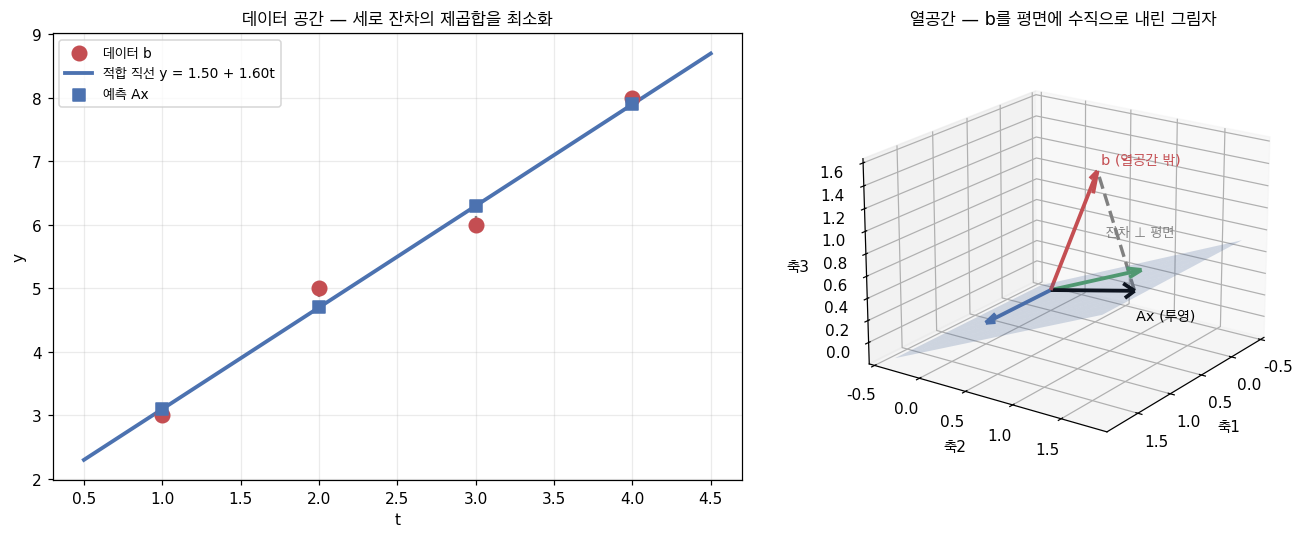

오른쪽 그림 검증: 잔차 · 1번 열 = 0.00e+00, 잔차 · 2번 열 = -3.34e-16
두 값이 모두 0 — 잔차가 평면(열공간)에 정확히 수직입니다. 이게 최소제곱의 전부입니다.


In [14]:
fig = plt.figure(figsize=(13, 5))

# 왼쪽: 데이터 공간에서의 회귀선
ax1 = fig.add_subplot(1, 2, 1)
t = A_over[:, 1]
ax1.scatter(t, b_over, s=90, color="#c44e52", zorder=5, label="데이터 b")
tt = np.linspace(0.5, 4.5, 50)
ax1.plot(tt, x_ls[0] + x_ls[1] * tt, lw=2.5, color="#4c72b0",
         label=f"적합 직선 y = {x_ls[0]:.2f} + {x_ls[1]:.2f}t")
for ti, bi, fi in zip(t, b_over, A_over @ x_ls):
    ax1.plot([ti, ti], [bi, fi], color="gray", lw=1.6, ls="--")
ax1.scatter(t, A_over @ x_ls, s=60, color="#4c72b0", zorder=5, marker="s", label="예측 Ax")
ax1.set_xlabel("t"); ax1.set_ylabel("y")
ax1.set_title("데이터 공간 — 세로 잔차의 제곱합을 최소화", fontsize=11.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.25)

# 오른쪽: 3D 열공간 투영 그림 (3차원 예시로 축소)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
A3 = np.array([[1.0, 0], [0, 1], [0, 0.4]])
b3 = np.array([1.0, 1.2, 1.6])
x3 = np.linalg.lstsq(A3, b3, rcond=None)[0]
proj = A3 @ x3

uu, vv = np.meshgrid(np.linspace(-0.4, 1.8, 12), np.linspace(-0.4, 1.8, 12))
plane = uu[..., None] * A3[:, 0] + vv[..., None] * A3[:, 1]
ax2.plot_surface(plane[..., 0], plane[..., 1], plane[..., 2], alpha=0.22, color="#4c72b0")

for col, c, lab in [(A3[:, 0], "#4c72b0", "A의 1번 열"), (A3[:, 1], "#55a868", "A의 2번 열")]:
    ax2.quiver(0, 0, 0, *col, color=c, lw=2.5, arrow_length_ratio=0.15)
ax2.quiver(0, 0, 0, *b3, color="#c44e52", lw=2.5, arrow_length_ratio=0.12)
ax2.quiver(0, 0, 0, *proj, color="black", lw=2.5, arrow_length_ratio=0.12)
ax2.plot([proj[0], b3[0]], [proj[1], b3[1]], [proj[2], b3[2]],
         color="gray", lw=2.2, ls="--")
ax2.text(*(b3 * 1.06), "b (열공간 밖)", fontsize=9.5, color="#c44e52")
ax2.text(*(proj * 1.02 - np.array([0, 0, 0.25])), "Ax (투영)", fontsize=9.5)
ax2.text(*((b3 + proj) / 2 + np.array([0.15, 0, 0])), "잔차 ⊥ 평면", fontsize=9, color="gray")
ax2.set_title("열공간 — b를 평면에 수직으로 내린 그림자", fontsize=11.5)
ax2.set_xlabel("축1"); ax2.set_ylabel("축2"); ax2.set_zlabel("축3")
ax2.view_init(elev=20, azim=35)

plt.tight_layout()
plt.show()

print(f"오른쪽 그림 검증: 잔차 · 1번 열 = {(b3-proj) @ A3[:,0]:.2e}, "
      f"잔차 · 2번 열 = {(b3-proj) @ A3[:,1]:.2e}")
print("두 값이 모두 0 — 잔차가 평면(열공간)에 정확히 수직입니다. 이게 최소제곱의 전부입니다.")

## 8️⃣ 🔑 정규방정식 = 선형회귀 (그리고 릿지)

여기서 연결이 **정확히** 맞아떨어집니다.

선형회귀에서 데이터 행렬 `X`는 행이 샘플, 열이 특징입니다. 타깃 `y`는 샘플마다 하나씩이고요.
가중치 `w`가 만족하는 식은:

$$X^\top X\,w = X^\top y \quad\Longrightarrow\quad w = (X^\top X)^{-1}X^\top y$$

**이게 선형회귀의 닫힌 해입니다.** `sklearn.linear_model.LinearRegression.fit()` 호출이
내부에서 이걸(혹은 QR/SVD를 통한 동등한 계산을) 하고 있어요.

### 📐 릿지회귀는 항 하나만 더합니다

$$(X^\top X + \lambda I)\,w = X^\top y$$

`λI`를 더하는 것이 하는 일이 **두 가지**입니다.

1. **가중치를 0 쪽으로 줄여** 과적합을 막습니다 (5주차에서 본 그 L2 정규화)
2. **행렬의 조건을 개선**해서 수치적으로 안전하게 만듭니다 ← 이번 주의 관점

그리고 `λ > 0`이면 `XᵀX + λI`는 **항상 대칭 양정부호**입니다.
그래서 **촐레스키로 풀 수 있습니다.** 6절이 여기서 쓰이는 겁니다.

> ⚠️ **실무 주의:** 정규방정식은 이해에는 최고지만, 실제로 쓸 때는 조심해야 합니다.
> `XᵀX`를 만드는 순간 **조건수가 제곱**되거든요. `cond(XᵀX) = cond(X)²` 입니다.
> 그래서 수치적으로 민감한 상황에서는 `XᵀX`를 만들지 않는 **QR이나 SVD**를 씁니다.
> 10절에서 이 문제를 정면으로 다룹니다.

In [15]:
def ridge_via_cholesky(X, y, lam):
    X = np.asarray(X, dtype=float)
    n_feat = X.shape[1]
    A = X.T @ X + lam * np.eye(n_feat)      # λ>0 이면 항상 대칭 양정부호
    L = cholesky(A)
    return cholesky_solve(L, X.T @ y)

rng = np.random.default_rng(42)
n, d = 100, 3
X_raw = rng.normal(size=(n, d))
w_true = np.array([2.0, -1.0, 0.5])
y = X_raw @ w_true + rng.normal(0, 0.1, n)
X = np.column_stack([np.ones(n), X_raw])

w_ols = least_squares_normal(X, y)
w_np = np.linalg.lstsq(X, y, rcond=None)[0]
print("[OLS — 정규화 없음]")
print(f"  내 정규방정식 : {np.round(w_ols, 6)}")
print(f"  np.linalg.lstsq: {np.round(w_np, 6)}")
print(f"  최대 차이      : {np.abs(w_ols - w_np).max():.2e}")

print("\n[릿지 — 촐레스키로 풀이]")
from sklearn.linear_model import Ridge
for lam in [0.0001, 1.0, 100.0]:
    w_ridge = ridge_via_cholesky(X, y, lam)
    sk = Ridge(alpha=lam, fit_intercept=False).fit(X, y)
    print(f"  λ={lam:<8} 내 구현 {np.round(w_ridge, 5)}")
    print(f"  {'':<11} sklearn {np.round(sk.coef_, 5)}   최대 차이 {np.abs(w_ridge-sk.coef_).max():.2e}")

print("\n[λ가 커질수록 가중치가 0 쪽으로 줄어듭니다]")
print(f"{'λ':>10}{'‖w‖₂':>12}{'w 값':>36}")
print("-" * 60)
for lam in [0.0, 0.01, 1.0, 10.0, 100.0, 1000.0]:
    w = ridge_via_cholesky(X, y, lam) if lam > 0 else w_ols
    print(f"{lam:>10.2f}{np.linalg.norm(w):>12.4f}   {np.round(w, 4)}")

[OLS — 정규화 없음]
  내 정규방정식 : [ 0.00877  2.00056 -0.99302  0.48025]
  np.linalg.lstsq: [ 0.00877  2.00056 -0.99302  0.48025]
  최대 차이      : 4.51e-16

[릿지 — 촐레스키로 풀이]
  λ=0.0001   내 구현 [ 0.00877  2.00056 -0.99302  0.48025]
              sklearn [ 0.00877  2.00056 -0.99302  0.48025]   최대 차이 1.11e-16
  λ=1.0      내 구현 [ 0.00751  1.97556 -0.98033  0.47251]
              sklearn [ 0.00751  1.97556 -0.98033  0.47251]   최대 차이 4.44e-16
  λ=100.0    내 구현 [-0.02035  0.88342 -0.43563  0.17819]
              sklearn [-0.02035  0.88342 -0.43563  0.17819]   최대 차이 2.78e-17

[λ가 커질수록 가중치가 0 쪽으로 줄어듭니다]
         λ        ‖w‖₂                                 w 값
------------------------------------------------------------
      0.00      2.2845   [ 0.0088  2.0006 -0.993   0.4803]
      0.01      2.2842   [ 0.0088  2.0003 -0.9929  0.4802]
      1.00      2.2555   [ 0.0075  1.9756 -0.9803  0.4725]
     10.00      2.0241   [-0.0016  1.7759 -0.8794  0.4124]
    100.00      1.0012   [-0.0203  0.8834 -0.4356  0.1

## 9️⃣ 유사역행렬 (무어-펜로즈) — 어떤 행렬이든 받아주는 만능키

역행렬은 **정사각이고 정칙인** 행렬에만 존재합니다.
유사역행렬 `A⁺`는 이 개념을 **모든 행렬**로 확장합니다.

4주차의 SVD를 이용합니다. `A = UΣVᵀ` 라면:

$$A^+ = V\Sigma^+U^\top$$

`Σ⁺`는 **0이 아닌 특이값들의 역수를 취하고 전치**한 것입니다. 그게 전부예요.

### 🔑 세 가지 상황을 하나로 처리합니다

| 시스템의 상태 | `A⁺b`가 주는 것 |
| --- | --- |
| 해가 하나 | 바로 그 해 |
| 해가 없음 (과결정) | **최소제곱 해** |
| 해가 무한 (부족결정) | 그중 **‖x‖가 가장 작은 해** |

마지막 줄이 특히 중요합니다. 특징이 샘플보다 많은(`d > n`) 상황에서
정규방정식은 `XᵀX`가 특이 행렬이라 **풀 수 없는데**, 유사역행렬은 답을 줍니다.
그리고 그 답은 **최소 노름 해** — 즉 암묵적으로 정규화된 해입니다.

`np.linalg.lstsq`와 `np.linalg.pinv` 모두 내부에서 SVD를 씁니다.

In [16]:
def pinv_from_svd(A, rcond=1e-12):
    U, s, Vt = np.linalg.svd(np.asarray(A, dtype=float), full_matrices=False)
    cutoff = rcond * s.max()
    s_inv = np.array([1 / si if si > cutoff else 0.0 for si in s])   # 작은 특이값은 버립니다
    return Vt.T @ np.diag(s_inv) @ U.T

print("[상황 1] 과결정 — 유사역행렬이 최소제곱 해를 줍니다")
x_pinv = pinv_from_svd(A_over) @ b_over
print(f"  유사역행렬 : {np.round(x_pinv, 6)}")
print(f"  정규방정식 : {np.round(x_ls, 6)}")
print(f"  차이       : {np.abs(x_pinv - x_ls).max():.2e}")

print("\n[상황 2] 부족결정 (미지수 > 방정식) — 해가 무한히 많습니다")
A_under = np.array([[1.0, 1, 1]])
b_under = np.array([6.0])
x_min = pinv_from_svd(A_under) @ b_under
print(f"  A = {A_under},  b = {b_under}")
print(f"  유사역행렬 해 : {np.round(x_min, 6)}   ‖x‖ = {np.linalg.norm(x_min):.6f}")
print("  다른 유효한 해들과 노름 비교:")
for cand in [[6.0, 0, 0], [3.0, 3, 0], [4.0, 1, 1], [2.5, 2.5, 1.0]]:
    cand = np.array(cand)
    ok = np.isclose(A_under @ cand, b_under)[0]
    print(f"    {cand}  방정식 만족 {ok},  ‖x‖ = {np.linalg.norm(cand):.6f}")
print("  => 전부 유효한 해인데, 유사역행렬은 그중 노름이 가장 작은 것을 고릅니다.")

print("\n[상황 3] 특징 > 샘플 — 정규방정식은 아예 못 풉니다")
rng = np.random.default_rng(11)
X_wide = rng.normal(size=(5, 12))            # 샘플 5개, 특징 12개
y_wide = rng.normal(size=5)
XtX = X_wide.T @ X_wide
print(f"  XᵀX 크기 {XtX.shape},  랭크 {np.linalg.matrix_rank(XtX)}  <- 12보다 작으면 특이 행렬")
try:
    np.linalg.solve(XtX, X_wide.T @ y_wide)
except np.linalg.LinAlgError as e:
    print(f"  np.linalg.solve → LinAlgError: {e}")
w_pinv = pinv_from_svd(X_wide) @ y_wide
print(f"  유사역행렬은 답을 줍니다. ‖w‖ = {np.linalg.norm(w_pinv):.4f}")
print(f"  잔차 ‖Xw - y‖ = {np.linalg.norm(X_wide @ w_pinv - y_wide):.2e}  <- 완벽히 맞춥니다(해가 무한하므로)")
print(f"  np.linalg.pinv 대조: 최대 차이 {np.abs(w_pinv - np.linalg.pinv(X_wide) @ y_wide).max():.2e}")

[상황 1] 과결정 — 유사역행렬이 최소제곱 해를 줍니다
  유사역행렬 : [1.5 1.6]
  정규방정식 : [1.5 1.6]
  차이       : 3.77e-15

[상황 2] 부족결정 (미지수 > 방정식) — 해가 무한히 많습니다
  A = [[1. 1. 1.]],  b = [6.]
  유사역행렬 해 : [2. 2. 2.]   ‖x‖ = 3.464102
  다른 유효한 해들과 노름 비교:
    [6. 0. 0.]  방정식 만족 True,  ‖x‖ = 6.000000
    [3. 3. 0.]  방정식 만족 True,  ‖x‖ = 4.242641
    [4. 1. 1.]  방정식 만족 True,  ‖x‖ = 4.242641
    [2.5 2.5 1. ]  방정식 만족 True,  ‖x‖ = 3.674235
  => 전부 유효한 해인데, 유사역행렬은 그중 노름이 가장 작은 것을 고릅니다.

[상황 3] 특징 > 샘플 — 정규방정식은 아예 못 풉니다
  XᵀX 크기 (12, 12),  랭크 5  <- 12보다 작으면 특이 행렬
  유사역행렬은 답을 줍니다. ‖w‖ = 0.4412
  잔차 ‖Xw - y‖ = 5.25e-16  <- 완벽히 맞춥니다(해가 무한하므로)
  np.linalg.pinv 대조: 최대 차이 2.43e-17


## 🔟 조건수 — 이 답을 믿어도 되는가

이번 레슨의 진짜 결론입니다.

**조건수**는 입력이 조금 흔들릴 때 **해가 얼마나 크게 흔들리는지**를 나타냅니다.

$$\kappa(A) = \lVert A \rVert \cdot \lVert A^{-1} \rVert = \frac{\sigma_{\max}}{\sigma_{\min}}$$

`σ`는 특이값입니다(4주차 SVD). 즉 **가장 늘어나는 방향과 가장 줄어드는 방향의 비율**이에요.

```
잘 조건화됨 (κ ≈ 1):            불량 조건 (κ ≈ 10¹⁵):
b가 조금 변하면                  b가 조금 변하면
x도 조금 변한다                   x가 미친 듯이 변한다
```

### 📐 실무 판단 기준

| 조건수 | 의미 |
| --- | --- |
| κ < 100 | 안전합니다 |
| κ ≈ 10ᵏ | **유효숫자를 약 k자리 잃습니다** |
| κ ≈ 10¹⁶ (float64) | 답이 무의미합니다. 사실상 특이 행렬 |

두 번째 줄이 핵심입니다. float64는 유효숫자가 약 16자리인데,
조건수가 10¹⁰이면 **10자리를 잃고 6자리만 남습니다.**

### 🏭 ML에서는 언제 나쁜 조건이 생기나

**특징들이 거의 공선(collinear)일 때**입니다.
키(cm)와 키(inch)를 둘 다 특징으로 넣었다고 생각해 보세요. 두 열이 사실상 같은 정보라
`XᵀX`가 거의 특이 행렬이 됩니다.

**정규화가 조건수를 직접 고칩니다.**

$$\kappa(X^\top X) = \frac{\sigma_{\max}}{\sigma_{\min}} \;\longrightarrow\; \kappa(X^\top X + \lambda I) = \frac{\sigma_{\max}+\lambda}{\sigma_{\min}+\lambda}$$

`σ_min`이 0에 가까워도 `λ`가 바닥을 받쳐 줍니다.
8절에서 "릿지가 조건을 개선한다"고 했던 게 이 식입니다.

In [17]:
def condition_number(A):
    s = np.linalg.svd(np.asarray(A, dtype=float), compute_uv=False)
    return s[0] / s[-1]

print("[공선 특징이 조건수를 어떻게 망가뜨리나]")
rng = np.random.default_rng(21)
n = 200
f1 = rng.normal(size=n)
print(f"{'두 번째 특징의 노이즈':>22}{'cond(X)':>16}{'cond(XᵀX)':>18}{'잃는 자릿수':>14}")
print("-" * 72)
for noise in [1.0, 1e-2, 1e-4, 1e-6, 1e-8]:
    f2 = f1 + noise * rng.normal(size=n)      # 노이즈가 작을수록 f1과 판박이
    Xc = np.column_stack([np.ones(n), f1, f2])
    k1, k2 = condition_number(Xc), condition_number(Xc.T @ Xc)
    print(f"{noise:>22.0e}{k1:>16.2e}{k2:>18.2e}{math.log10(k2):>14.1f}")

print("\n=> cond(XᵀX) ≈ cond(X)² 입니다. 정규방정식을 만드는 순간 조건수가 제곱됩니다.")
print("   그래서 수치적으로 민감할 때는 XᵀX를 만들지 않는 QR/SVD를 씁니다 (8절 경고의 이유).")

[공선 특징이 조건수를 어떻게 망가뜨리나]
          두 번째 특징의 노이즈         cond(X)         cond(XᵀX)        잃는 자릿수
------------------------------------------------------------------------
                 1e+00        2.36e+00          5.55e+00           0.7
                 1e-02        1.76e+02          3.08e+04           4.5
                 1e-04        1.83e+04          3.35e+08           8.5
                 1e-06        1.82e+06          3.31e+12          12.5
                 1e-08        1.98e+08          1.12e+17          17.0

=> cond(XᵀX) ≈ cond(X)² 입니다. 정규방정식을 만드는 순간 조건수가 제곱됩니다.
   그래서 수치적으로 민감할 때는 XᵀX를 만들지 않는 QR/SVD를 씁니다 (8절 경고의 이유).


In [18]:
# 불량 조건 시스템에서 b를 아주 살짝 흔들어 봅니다
print("[입력의 미세한 변화가 해를 얼마나 흔드나]")
noise = 1e-7
f2 = f1 + noise * rng.normal(size=n)
X_ill = np.column_stack([np.ones(n), f1, f2])
w_true3 = np.array([1.0, 2.0, -1.0])
y_ill = X_ill @ w_true3

kappa = condition_number(X_ill.T @ X_ill)
print(f"  cond(XᵀX) = {kappa:.3e}\n")

print(f"{'λ (정규화)':>12}{'cond(XᵀX+λI)':>18}{'y를 1e-10 흔들 때 해의 변화':>32}")
print("-" * 64)
perturb = 1e-10 * rng.normal(size=n)
for lam in [0.0, 1e-8, 1e-4, 1e-2, 1.0]:
    A_reg = X_ill.T @ X_ill + lam * np.eye(3)
    k = condition_number(A_reg)
    w1 = np.linalg.solve(A_reg, X_ill.T @ y_ill)
    w2 = np.linalg.solve(A_reg, X_ill.T @ (y_ill + perturb))
    print(f"{lam:>12.0e}{k:>18.3e}{np.linalg.norm(w2-w1):>32.3e}")

print("\n=> λ를 조금만 넣어도 조건수가 급격히 떨어지고, 해가 안정됩니다.")
print("   릿지 정규화는 '과적합 방지'인 동시에 '수치적 안정화 장치'입니다.")

[입력의 미세한 변화가 해를 얼마나 흔드나]
  cond(XᵀX) = 3.631e+14

     λ (정규화)      cond(XᵀX+λI)             y를 1e-10 흔들 때 해의 변화
----------------------------------------------------------------
       0e+00         3.631e+14                       2.704e-01
       1e-08         3.245e+10                       2.411e-05
       1e-04         3.245e+06                       2.412e-09
       1e-02         3.245e+04                       2.419e-11
       1e+00         3.255e+02                       9.795e-12

=> λ를 조금만 넣어도 조건수가 급격히 떨어지고, 해가 안정됩니다.
   릿지 정규화는 '과적합 방지'인 동시에 '수치적 안정화 장치'입니다.


### 🖼️ 그림 6 — 조건수와 정규화

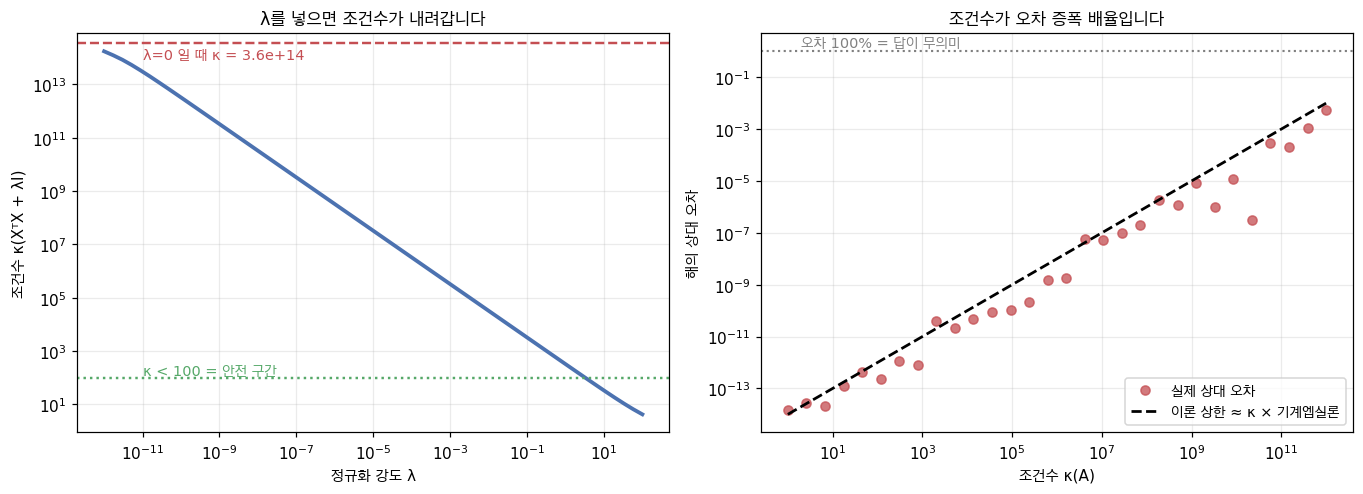

오른쪽 그림: 점들이 대각선(κ × 기계엡실론)을 따라갑니다.
즉 '입력 오차 × 조건수 = 출력 오차'라는 관계가 실제로 성립합니다.
κ = 10¹⁶ 근처에서는 상대 오차가 1에 도달합니다 — float64의 한계입니다.


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

# (1) 정규화가 조건수를 낮추는 모습
lams = np.logspace(-12, 2, 60)
XtX_ill = X_ill.T @ X_ill
conds = [condition_number(XtX_ill + l * np.eye(3)) for l in lams]
ax1.loglog(lams, conds, lw=2.5, color="#4c72b0")
ax1.axhline(condition_number(XtX_ill), color="#c44e52", ls="--", lw=1.6)
ax1.text(1e-11, condition_number(XtX_ill) * 0.25,
         f"λ=0 일 때 κ = {condition_number(XtX_ill):.1e}", fontsize=9.5, color="#c44e52")
ax1.axhline(100, color="#55a868", ls=":", lw=1.6)
ax1.text(1e-11, 130, "κ < 100 = 안전 구간", fontsize=9.5, color="#55a868")
ax1.set_xlabel("정규화 강도 λ"); ax1.set_ylabel("조건수 κ(XᵀX + λI)")
ax1.set_title("λ를 넣으면 조건수가 내려갑니다", fontsize=11.5)
ax1.grid(alpha=0.25, which="both")

# (2) 조건수 vs 실제 오차 증폭
kappas, errs = [], []
rng2 = np.random.default_rng(31)
for exp in np.linspace(0, 12, 30):
    nn = 6
    U_, _ = np.linalg.qr(rng2.normal(size=(nn, nn)))
    V_, _ = np.linalg.qr(rng2.normal(size=(nn, nn)))
    s = np.logspace(0, -exp, nn)
    M = U_ @ np.diag(s) @ V_.T
    x_true = rng2.normal(size=nn)
    bb = M @ x_true
    db = 1e-14 * np.linalg.norm(bb) * rng2.normal(size=nn)
    x_hat = np.linalg.solve(M, bb + db)
    kappas.append(condition_number(M))
    errs.append(np.linalg.norm(x_hat - x_true) / np.linalg.norm(x_true))

ax2.loglog(kappas, np.maximum(errs, 1e-18), "o", ms=6, color="#c44e52", alpha=0.75,
           label="실제 상대 오차")
kk = np.array(sorted(kappas))
ax2.loglog(kk, 1e-14 * kk, "--", color="black", lw=1.8, label="이론 상한 ≈ κ × 기계엡실론")
ax2.axhline(1.0, color="gray", ls=":", lw=1.4)
ax2.text(2, 1.5, "오차 100% = 답이 무의미", fontsize=9.5, color="gray")
ax2.set_xlabel("조건수 κ(A)"); ax2.set_ylabel("해의 상대 오차")
ax2.set_title("조건수가 오차 증폭 배율입니다", fontsize=11.5)
ax2.legend(fontsize=9.5); ax2.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.show()

print("오른쪽 그림: 점들이 대각선(κ × 기계엡실론)을 따라갑니다.")
print("즉 '입력 오차 × 조건수 = 출력 오차'라는 관계가 실제로 성립합니다.")
print(f"κ = 10¹⁶ 근처에서는 상대 오차가 1에 도달합니다 — float64의 한계입니다.")

## 1️⃣1️⃣ 켤레기울기법 — 행렬이 너무 클 때

미지수가 수백만 개인 **거대한 희소 시스템**에서는 LU나 촐레스키가 불가능합니다.
분해 결과가 메모리에 안 들어가거든요(희소 행렬을 분해하면 빽빽해집니다).

**반복법(iterative method)** 은 다르게 접근합니다.
정확한 해를 한 번에 구하지 않고, **추측을 조금씩 개선**해 나갑니다.

**켤레기울기법(CG)** 은 `A`가 대칭 양정부호일 때 쓰는 대표적인 반복법입니다.

```
x₀ = 초기 추측 (보통 0)
r₀ = b - Ax₀              (잔차)
p₀ = r₀                   (탐색 방향)

k = 0, 1, 2, ... 에 대해:
  α = (rₖ·rₖ) / (pₖ·Apₖ)
  x_{k+1} = xₖ + α·pₖ
  r_{k+1} = rₖ - α·Apₖ
  β = (r_{k+1}·r_{k+1}) / (rₖ·rₖ)
  p_{k+1} = r_{k+1} + β·pₖ
  ‖r‖ < 허용오차면 종료
```

### 🔑 핵심 성질 두 가지

1. **이론적으로 최대 `n`번 안에 정확한 해에 도달합니다** (정확한 산술 기준)
2. 실제로는 **고유값이 뭉쳐 있으면 훨씬 빨리** 수렴합니다

그리고 여기서도 조건수가 나옵니다. **수렴 속도가 `√κ`에 비례**합니다.

$$\text{오차}_k \le 2\left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)^k \text{오차}_0$$

**조건이 좋을수록 빨리 수렴합니다.** 정규화가 도움이 되는 또 하나의 이유죠.
그래서 실무에서는 **전처리(preconditioning)** 로 조건수를 인위적으로 낮춘 뒤 CG를 돌립니다.

### 🏭 어디에 쓰이나

대규모 최적화(Newton-CG) · 편미분방정식 이산화 · 커널 행렬이 너무 커서 분해 못 할 때 · 다른 반복법의 전처리

In [20]:
def conjugate_gradient(A, b, x0=None, tol=1e-10, max_iter=None):
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    n = len(b)
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float)
    r = b - A @ x
    p = r.copy()
    rs_old = r @ r
    history = [math.sqrt(rs_old)]
    max_iter = max_iter or n * 2

    for k in range(max_iter):
        Ap = A @ p
        alpha = rs_old / (p @ Ap)
        x += alpha * p
        r -= alpha * Ap
        rs_new = r @ r
        history.append(math.sqrt(rs_new))
        if math.sqrt(rs_new) < tol:
            break
        p = r + (rs_new / rs_old) * p
        rs_old = rs_new
    return x, history

rng = np.random.default_rng(101)
n = 100
Z = rng.normal(size=(n, n))
A_spd = Z @ Z.T / n + np.eye(n)              # 대칭 양정부호
b_cg = rng.normal(size=n)

x_cg, hist = conjugate_gradient(A_spd, b_cg)
x_exact = np.linalg.solve(A_spd, b_cg)

print(f"행렬 크기 {n}×{n},  조건수 {condition_number(A_spd):.2f}")
print(f"  CG 반복 횟수 : {len(hist)-1}회  (이론 최대 {n}회)")
print(f"  CG 해와 정확해의 차이 : {np.linalg.norm(x_cg - x_exact):.2e}")
print(f"  최종 잔차 ‖b - Ax‖    : {np.linalg.norm(A_spd @ x_cg - b_cg):.2e}")

print("\n[조건수가 수렴 속도를 결정합니다]")
CAP = 3000                                   # 상한에 걸렸는지 구분하려고 넉넉히 잡습니다
print(f"{'조건수 κ':>14}{'CG 반복 횟수':>16}{'√κ':>12}{'수렴?':>10}")
print("-" * 54)
for spread in [1, 10, 100, 1000, 10000]:
    d = np.logspace(0, math.log10(spread), n)
    Q_, _ = np.linalg.qr(rng.normal(size=(n, n)))
    A_k = Q_ @ np.diag(d) @ Q_.T
    A_k = (A_k + A_k.T) / 2                  # 대칭성 보장
    _, h = conjugate_gradient(A_k, b_cg, tol=1e-10, max_iter=CAP)
    conv = "예" if h[-1] < 1e-10 else "아니오"
    print(f"{condition_number(A_k):>14.1f}{len(h)-1:>16}{math.sqrt(condition_number(A_k)):>12.1f}{conv:>10}")
print("\n=> 반복 횟수가 √κ 와 같은 방향으로 늘어납니다.")
print("   다만 정확히 비례하지는 않습니다 — 고유값이 '어떻게 분포하느냐'도 함께 작용하기 때문입니다.")
print("   √κ 는 최악의 경우 상한이고, 고유값이 뭉쳐 있으면 훨씬 빨리 끝납니다.")

행렬 크기 100×100,  조건수 4.78
  CG 반복 횟수 : 25회  (이론 최대 100회)
  CG 해와 정확해의 차이 : 3.28e-11
  최종 잔차 ‖b - Ax‖    : 5.91e-11

[조건수가 수렴 속도를 결정합니다]
         조건수 κ        CG 반복 횟수          √κ       수렴?
------------------------------------------------------
           1.0               1         1.0         예
          10.0              38         3.2         예
         100.0              97        10.0         예
        1000.0             212        31.6         예
       10000.0             435       100.0         예

=> 반복 횟수가 √κ 와 같은 방향으로 늘어납니다.
   다만 정확히 비례하지는 않습니다 — 고유값이 '어떻게 분포하느냐'도 함께 작용하기 때문입니다.
   √κ 는 최악의 경우 상한이고, 고유값이 뭉쳐 있으면 훨씬 빨리 끝납니다.


### 🖼️ 그림 7 — CG의 수렴 곡선

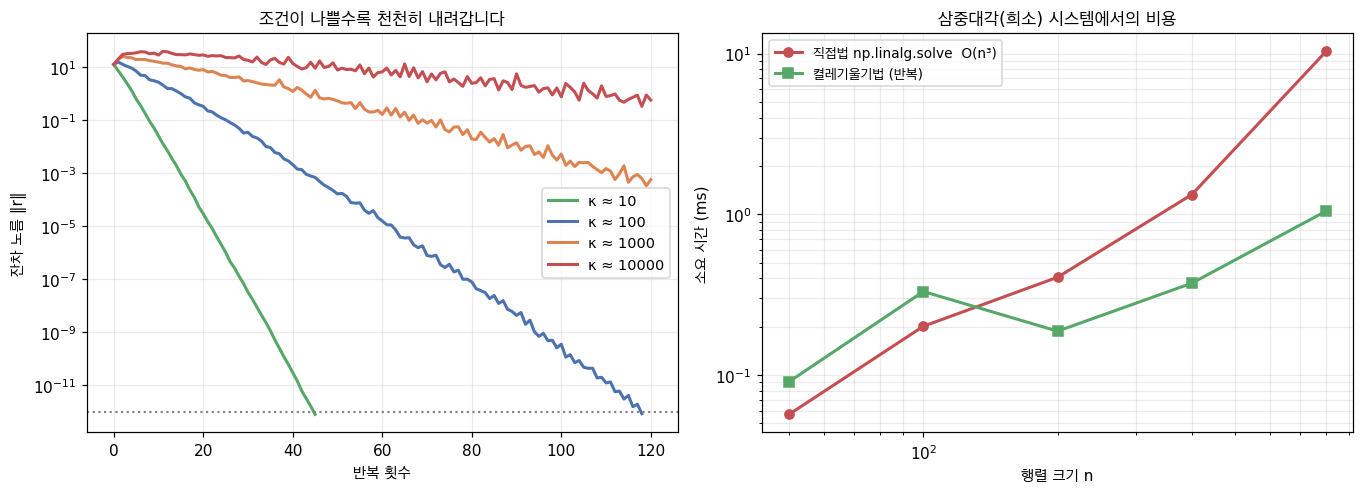

n=800 삼중대각 행렬에서 CG 반복 횟수: 21회  (이론 최대 800회)
고유값이 좁은 구간에 뭉쳐 있어서 훨씬 일찍 끝났습니다. 이게 CG의 실전 강점입니다.

⚠️ 단, 이 데모는 밀집 행렬로 계산했습니다. 진짜 이득은 scipy.sparse를 써서
   행렬-벡터 곱을 O(nnz)로 만들 때 나옵니다. 그때 CG는 n이 수백만이어도 동작합니다.


In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

rng = np.random.default_rng(55)
n = 120
b_test = rng.normal(size=n)
for spread, color in zip([10, 100, 1000, 10000], ["#55a868", "#4c72b0", "#dd8452", "#c44e52"]):
    d = np.logspace(0, math.log10(spread), n)
    Q_, _ = np.linalg.qr(rng.normal(size=(n, n)))
    A_k = Q_ @ np.diag(d) @ Q_.T
    A_k = (A_k + A_k.T) / 2
    _, h = conjugate_gradient(A_k, b_test, tol=1e-12, max_iter=n)
    kap = condition_number(A_k)
    ax1.semilogy(h, lw=2, color=color, label=f"κ ≈ {kap:.0f}")
ax1.axhline(1e-12, color="gray", ls=":", lw=1.4)
ax1.set_xlabel("반복 횟수"); ax1.set_ylabel("잔차 노름 ‖r‖")
ax1.set_title("조건이 나쁠수록 천천히 내려갑니다", fontsize=11.5)
ax1.legend(fontsize=9.5); ax1.grid(alpha=0.25, which="both")

# 밀집 직접법 vs CG 비용 비교 (희소 행렬 기준)
sizes = [50, 100, 200, 400, 800]
t_direct, t_cg = [], []
for m in sizes:
    main = 4.0 * np.ones(m)
    off = -1.0 * np.ones(m - 1)
    A_tri = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)   # 삼중대각 = 희소
    bb = rng.normal(size=m)
    t_direct.append(time_it(lambda A_tri=A_tri, bb=bb: np.linalg.solve(A_tri, bb)))
    t_cg.append(time_it(lambda A_tri=A_tri, bb=bb: conjugate_gradient(A_tri, bb, tol=1e-10)))

ax2.loglog(sizes, np.array(t_direct) * 1000, "o-", color="#c44e52", lw=2,
           label="직접법 np.linalg.solve  O(n³)")
ax2.loglog(sizes, np.array(t_cg) * 1000, "s-", color="#55a868", lw=2,
           label="켤레기울기법 (반복)")
ax2.set_xlabel("행렬 크기 n"); ax2.set_ylabel("소요 시간 (ms)")
ax2.set_title("삼중대각(희소) 시스템에서의 비용", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.show()

_, h_tri = conjugate_gradient(np.diag(4.0*np.ones(800)) + np.diag(-1.0*np.ones(799), 1)
                              + np.diag(-1.0*np.ones(799), -1), rng.normal(size=800), tol=1e-10)
print(f"n=800 삼중대각 행렬에서 CG 반복 횟수: {len(h_tri)-1}회  (이론 최대 800회)")
print("고유값이 좁은 구간에 뭉쳐 있어서 훨씬 일찍 끝났습니다. 이게 CG의 실전 강점입니다.")
print("\n⚠️ 단, 이 데모는 밀집 행렬로 계산했습니다. 진짜 이득은 scipy.sparse를 써서")
print("   행렬-벡터 곱을 O(nnz)로 만들 때 나옵니다. 그때 CG는 n이 수백만이어도 동작합니다.")

## 1️⃣2️⃣ 🏭 어떤 방법을 언제 쓰나

| 방법 | 조건 | 비용 | 쓰는 상황 |
| --- | --- | --- | --- |
| **가우스 소거** | 정사각·정칙 | O(n³) | 정사각 시스템 한 번 풀기 |
| **LU 분해** | 정사각·정칙 | O(n³) 분해 + O(n²) 풀이 | **같은 A로 여러 b** |
| **QR 분해** | 임의 (m ≥ n) | O(mn²) | **최소제곱, 수치 안정성 필요할 때** |
| **촐레스키** | 대칭 양정부호 | O(n³/3) | **공분산, GP 커널, 릿지** |
| **정규방정식** | 과결정 (m > n) | O(mn² + n³) | 선형회귀 (n이 작고 조건이 좋을 때) |
| **SVD / 유사역행렬** | 임의 | O(mn²) | **랭크 부족, 최소 노름 해** |
| **켤레기울기법** | 대칭 양정부호·희소 | O(n·k·nnz) | **초대형 희소 시스템** |

### 🏭 ML 현장에서의 등장 지점

**선형회귀** — 정규방정식 `XᵀXw = Xᵀy`를 풉니다. `n`이 작으면 촐레스키,
수치 안정성이 중요하면 QR, 랭크가 부족할 수 있으면 SVD를 씁니다.

**릿지회귀** — `XᵀX + λI`는 `λ > 0`에서 항상 대칭 양정부호라 **촐레스키가 항상 통합니다.**

**가우시안 프로세스** — 커널 행렬 `K`를 촐레스키 분해하고 `Kα = y`를 풉니다.
로그 주변우도에 필요한 `log det(K) = 2Σlog(Lᵢᵢ)`도 같은 분해에서 나옵니다.

**신경망 초기화** — 직교 초기화가 **QR 분해**로 직교 가중치 행렬을 만듭니다.
깊은 망에서 신호가 붕괴하는 걸 막습니다.

**전처리(preconditioning)** — 대규모 최적화기가 불완전 촐레스키/LU를 CG의 전처리로 씁니다.

**특징 공학** — `cond(XᵀX)`가 크면 특징이 공선이라는 신호입니다. 특징을 빼거나 정규화를 넣으세요.

In [22]:
# 🏭 직교 초기화 — QR 분해가 딥러닝에 쓰이는 실제 사례
rng = np.random.default_rng(7)
DIM, DEPTH = 128, 60

def propagate(init_fn, depth=DEPTH):
    # 활성화 없이 선형으로만 쌓습니다. QR의 '길이 보존' 성질만 순수하게 보려는 것입니다.
    x = rng.normal(size=DIM)
    x /= np.linalg.norm(x)
    norms = []
    for _ in range(depth):
        x = init_fn() @ x
        norms.append(np.linalg.norm(x))
    return np.array(norms)

def gaussian_init(gain):
    return rng.normal(size=(DIM, DIM)) * gain / math.sqrt(DIM)

def orthogonal_init():
    Q, R = np.linalg.qr(rng.normal(size=(DIM, DIM)))
    return Q * np.sign(np.diag(R))            # 부호를 맞춰 진짜 직교 행렬로

n_big = propagate(lambda: gaussian_init(1.15))
n_small = propagate(lambda: gaussian_init(0.85))
n_orth = propagate(orthogonal_init)

print("60개 선형층을 통과한 뒤 신호의 노름 (시작 노름 = 1)")
print(f"{'층':>6}{'가우시안 gain 1.15':>22}{'가우시안 gain 0.85':>22}{'직교 (QR)':>16}")
print("-" * 68)
for i in [0, 9, 29, 59]:
    print(f"{i+1:>6}{n_big[i]:>22.4e}{n_small[i]:>22.4e}{n_orth[i]:>16.6f}")

print(f"\n=> 가우시안은 스케일을 조금만 잘못 잡아도 지수적으로 폭발하거나(gain 1.15) 소멸합니다(gain 0.85).")
print(f"   직교 초기화는 60층을 지나도 노름이 정확히 {n_orth[-1]:.6f} — 1에서 변하지 않습니다.")
print("   직교 행렬은 회전/반사만 하므로 길이를 정확히 보존하기 때문입니다 (5절의 QᵀQ = I).")
print("   PyTorch의 torch.nn.init.orthogonal_ 이 정확히 이 QR 분해를 씁니다.")

60개 선형층을 통과한 뒤 신호의 노름 (시작 노름 = 1)
     층        가우시안 gain 1.15        가우시안 gain 0.85         직교 (QR)
--------------------------------------------------------------------
     1            1.1805e+00            8.6854e-01        1.000000
    10            3.9665e+00            1.7234e-01        1.000000
    30            7.1094e+01            4.7909e-03        1.000000
    60            5.3120e+03            7.0363e-05        1.000000

=> 가우시안은 스케일을 조금만 잘못 잡아도 지수적으로 폭발하거나(gain 1.15) 소멸합니다(gain 0.85).
   직교 초기화는 60층을 지나도 노름이 정확히 1.000000 — 1에서 변하지 않습니다.
   직교 행렬은 회전/반사만 하므로 길이를 정확히 보존하기 때문입니다 (5절의 QᵀQ = I).
   PyTorch의 torch.nn.init.orthogonal_ 이 정확히 이 QR 분해를 씁니다.


## 1️⃣3️⃣ 📝 연습문제 (풀이 포함)

1. `[[1,2,3],[4,5,6],[7,8,10]] x = [6,15,27]` 을 가우스 소거·LU·`np.linalg.solve` 세 가지로 풀고 일치를 확인하기.
2. 50×5 무작위 `X`와 `y = Xw + 노이즈`에 대해 정규방정식·QR·SVD·`lstsq` 네 방법을 비교하고, `cond(XᵀX)`가 신뢰도에 어떤 영향을 주는지 설명하기.
3. 거의 특이한 행렬(두 열이 거의 동일)을 만들어 조건수를 재고, 정규화 유무에 따른 해와 잔차를 비교하기.
4. 100×100 대칭 양정부호 행렬에 켤레기울기법을 돌려 `1e-8` 수렴까지의 반복 횟수를 세고 이론 최대치 `n`과 비교하기.
5. 촐레스키·LU·`np.linalg.solve`의 속도를 크기 10/50/200/500에서 재고 촐레스키가 약 2배 빠른지 확인하기. *(→ 6절 그림 4에서 완료)*

In [23]:
print("=" * 74)
print("연습 1 — 세 가지 방법의 일치 확인")
print("=" * 74)
A1 = np.array([[1.0, 2, 3], [4, 5, 6], [7, 8, 10]])
b1 = np.array([6.0, 15, 27])

x_gauss = gaussian_elimination(A1, b1)
P1, L1, U1 = lu_decompose(A1)
x_lu = lu_solve(P1, L1, U1, b1)
x_np = np.linalg.solve(A1, b1)

print(f"  가우스 소거      : {np.round(x_gauss, 10)}")
print(f"  LU 분해          : {np.round(x_lu, 10)}")
print(f"  np.linalg.solve  : {np.round(x_np, 10)}")
print(f"\n  가우스 vs NumPy 최대 차이: {np.abs(x_gauss - x_np).max():.2e}")
print(f"  LU     vs NumPy 최대 차이: {np.abs(x_lu - x_np).max():.2e}")
print(f"  조건수 κ(A) = {condition_number(A1):.2f}  <- 작아서 세 방법 모두 신뢰할 만합니다")
print(f"  검증 Ax = {A1 @ x_np}  (b = {b1})")

연습 1 — 세 가지 방법의 일치 확인
  가우스 소거      : [ 3. -3.  3.]
  LU 분해          : [ 3. -3.  3.]
  np.linalg.solve  : [ 3. -3.  3.]

  가우스 vs NumPy 최대 차이: 1.78e-15
  LU     vs NumPy 최대 차이: 4.88e-15
  조건수 κ(A) = 88.45  <- 작아서 세 방법 모두 신뢰할 만합니다
  검증 Ax = [ 6. 15. 27.]  (b = [ 6. 15. 27.])


In [24]:
print("=" * 74)
print("연습 2 — 네 가지 최소제곱 방법 비교")
print("=" * 74)
rng = np.random.default_rng(2024)
m, d = 50, 5
X2 = rng.normal(size=(m, d))
w_true2 = np.array([1.5, -2.0, 0.7, 3.1, -0.4])
y2 = X2 @ w_true2 + rng.normal(0, 0.05, m)

# 방법 1: 정규방정식
w_ne = np.linalg.solve(X2.T @ X2, X2.T @ y2)
# 방법 2: QR
Q2, R2 = np.linalg.qr(X2)
w_qr = np.linalg.solve(R2, Q2.T @ y2)
# 방법 3: SVD
U2, s2, Vt2 = np.linalg.svd(X2, full_matrices=False)
w_svd = Vt2.T @ ((U2.T @ y2) / s2)
# 방법 4: lstsq
w_lstsq = np.linalg.lstsq(X2, y2, rcond=None)[0]

print(f"  참 계수      : {w_true2}")
print(f"  정규방정식   : {np.round(w_ne, 8)}")
print(f"  QR           : {np.round(w_qr, 8)}")
print(f"  SVD          : {np.round(w_svd, 8)}")
print(f"  lstsq        : {np.round(w_lstsq, 8)}")
print(f"\n  네 방법의 최대 상호 차이: "
      f"{max(np.abs(a-b).max() for a in [w_ne,w_qr,w_svd] for b in [w_lstsq]):.2e}")
print(f"  cond(X)   = {condition_number(X2):.2f}")
print(f"  cond(XᵀX) = {condition_number(X2.T @ X2):.2f}  ≈ cond(X)² = {condition_number(X2)**2:.2f}")
print("\n  => 조건이 좋으면(κ~10) 네 방법이 사실상 동일합니다.")
print("     차이는 조건이 나쁠 때 드러납니다. 아래에서 확인합니다.")

print("\n[조건을 일부러 나쁘게 만들면]")
X3 = X2.copy()
X3[:, 1] = X3[:, 0] + 1e-9 * rng.normal(size=m)      # 두 열을 거의 동일하게
y3 = X3 @ w_true2 + rng.normal(0, 0.05, m)
print(f"  cond(X)   = {condition_number(X3):.3e}")
print(f"  cond(XᵀX) = {condition_number(X3.T @ X3):.3e}")
w_ne3 = np.linalg.solve(X3.T @ X3, X3.T @ y3)
w_svd3 = np.linalg.lstsq(X3, y3, rcond=None)[0]
print(f"  정규방정식 잔차 : {np.linalg.norm(X3 @ w_ne3 - y3):.6f}")
print(f"  SVD(lstsq) 잔차 : {np.linalg.norm(X3 @ w_svd3 - y3):.6f}")
print(f"  두 해의 거리    : {np.linalg.norm(w_ne3 - w_svd3):.3e}  <- 답이 갈라졌습니다")
print("  => 이때는 SVD 기반(lstsq)을 믿으세요. XᵀX를 만들지 않으니까요.")

연습 2 — 네 가지 최소제곱 방법 비교
  참 계수      : [ 1.5 -2.   0.7  3.1 -0.4]
  정규방정식   : [ 1.51211 -2.0057   0.6877   3.10766 -0.39095]
  QR           : [ 1.51211 -2.0057   0.6877   3.10766 -0.39095]
  SVD          : [ 1.51211 -2.0057   0.6877   3.10766 -0.39095]
  lstsq        : [ 1.51211 -2.0057   0.6877   3.10766 -0.39095]

  네 방법의 최대 상호 차이: 2.00e-15
  cond(X)   = 1.51
  cond(XᵀX) = 2.29  ≈ cond(X)² = 2.29

  => 조건이 좋으면(κ~10) 네 방법이 사실상 동일합니다.
     차이는 조건이 나쁠 때 드러납니다. 아래에서 확인합니다.

[조건을 일부러 나쁘게 만들면]
  cond(X)   = 1.905e+09
  cond(XᵀX) = 7.173e+15
  정규방정식 잔차 : 0.375956
  SVD(lstsq) 잔차 : 0.372209
  두 해의 거리    : 1.110e+07  <- 답이 갈라졌습니다
  => 이때는 SVD 기반(lstsq)을 믿으세요. XᵀX를 만들지 않으니까요.


In [25]:
print("=" * 74)
print("연습 3 — 거의 특이한 행렬과 정규화")
print("=" * 74)
rng = np.random.default_rng(77)
nn = 80
c1 = rng.normal(size=nn)
c2 = c1 + 1e-10 * rng.normal(size=nn)          # 사실상 같은 열
A3 = np.column_stack([c1, c2, rng.normal(size=nn)])
w_t = np.array([1.0, 1.0, 2.0])
b3 = A3 @ w_t

print(f"  cond(A)   = {condition_number(A3):.3e}")
print(f"  cond(AᵀA) = {condition_number(A3.T @ A3):.3e}\n")
print(f"{'λ':>10}{'‖w‖':>14}{'잔차 ‖Aw-b‖':>18}{'cond(AᵀA+λI)':>18}")
print("-" * 62)
for lam in [0.0, 1e-10, 1e-6, 1e-3, 1.0]:
    M = A3.T @ A3 + lam * np.eye(3)
    w = np.linalg.solve(M, A3.T @ b3)
    print(f"{lam:>10.0e}{np.linalg.norm(w):>14.4f}"
          f"{np.linalg.norm(A3 @ w - b3):>18.3e}{condition_number(M):>18.3e}")

print("\n  💡 읽는 법:")
print(f"     λ=0: 잔차는 작지만 ‖w‖가 커지고 조건수가 {condition_number(A3.T @ A3):.1e}입니다. 답을 믿을 수 없습니다.")
print("     λ를 키우면: ‖w‖가 안정되고 조건수가 내려갑니다. 잔차는 아주 조금 나빠집니다.")
print("     이게 '편향-분산 트레이드오프'의 수치해석 버전입니다.")

연습 3 — 거의 특이한 행렬과 정규화
  cond(A)   = 2.109e+10
  cond(AᵀA) = 1.052e+16

         λ           ‖w‖         잔차 ‖Aw-b‖      cond(AᵀA+λI)
--------------------------------------------------------------
     0e+00       10.7986         6.401e-09         1.052e+16
     1e-10        2.4495         2.679e-11         1.648e+12
     1e-06        2.4495         2.678e-07         1.648e+08
     1e-03        2.4495         2.678e-04         1.648e+05
     1e+00        2.4206         2.645e-01         1.658e+02

  💡 읽는 법:
     λ=0: 잔차는 작지만 ‖w‖가 커지고 조건수가 1.1e+16입니다. 답을 믿을 수 없습니다.
     λ를 키우면: ‖w‖가 안정되고 조건수가 내려갑니다. 잔차는 아주 조금 나빠집니다.
     이게 '편향-분산 트레이드오프'의 수치해석 버전입니다.


In [26]:
print("=" * 74)
print("연습 4 — 켤레기울기법 반복 횟수")
print("=" * 74)
rng = np.random.default_rng(303)
n4 = 100
Z4 = rng.normal(size=(n4, n4))
A4 = Z4 @ Z4.T / n4 + 0.5 * np.eye(n4)
b4 = rng.normal(size=n4)

x4, h4 = conjugate_gradient(A4, b4, tol=1e-8)
kap4 = condition_number(A4)
print(f"  행렬 크기 n = {n4},  조건수 κ = {kap4:.2f}")
print(f"  1e-8 수렴까지 반복 : {len(h4)-1}회")
print(f"  이론 최대치 n      : {n4}회")
print(f"  √κ                : {math.sqrt(kap4):.1f}")
print(f"  정확해와의 차이    : {np.linalg.norm(x4 - np.linalg.solve(A4, b4)):.2e}")

print(f"\n  잔차 감소 과정 (10회마다)")
for k in range(0, len(h4), max(1, (len(h4)-1)//8)):
    print(f"    {k:>4}회: ‖r‖ = {h4[k]:.4e}")

print(f"\n  => n={n4}인데 {len(h4)-1}회 만에 끝났습니다. 이론 최대치의 "
      f"{(len(h4)-1)/n4*100:.0f}% 수준입니다.")
print("     고유값이 뭉쳐 있으면 CG는 n보다 훨씬 일찍 수렴합니다.")

연습 4 — 켤레기울기법 반복 횟수
  행렬 크기 n = 100,  조건수 κ = 9.06
  1e-8 수렴까지 반복 : 28회
  이론 최대치 n      : 100회
  √κ                : 3.0
  정확해와의 차이    : 5.48e-09

  잔차 감소 과정 (10회마다)
       0회: ‖r‖ = 9.9577e+00
       3회: ‖r‖ = 1.4870e+00
       6회: ‖r‖ = 1.8140e-01
       9회: ‖r‖ = 2.0777e-02
      12회: ‖r‖ = 2.1001e-03
      15회: ‖r‖ = 2.1367e-04
      18회: ‖r‖ = 1.7120e-05
      21회: ‖r‖ = 1.7411e-06
      24회: ‖r‖ = 1.5041e-07
      27회: ‖r‖ = 1.4292e-08

  => n=100인데 28회 만에 끝났습니다. 이론 최대치의 28% 수준입니다.
     고유값이 뭉쳐 있으면 CG는 n보다 훨씬 일찍 수렴합니다.


## 1️⃣4️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 사람들이 말하는 것 | 실제 의미 |
| --- | --- | --- |
| **선형 시스템** | "x를 구해라" | `Ax = b`. 변환 `A`를 거쳐 `b`가 나오게 하는 입력 `x`를 찾는 것 |
| **가우스 소거법** | "행 줄이기" | 행 연산으로 대각선 아래를 0으로 만들어 상삼각 시스템을 만든 뒤 후진 대입. O(n³) |
| **부분 피벗팅** | "안정성을 위해 행 바꾸기" | k열에서 절댓값 최대인 행을 피벗 자리로. 승수를 \|m\|≤1로 묶어 오차 증폭을 막습니다 |
| **LU 분해** | "삼각행렬로 쪼개기" | `A = LU`. O(n³)를 한 번만 내고 이후 풀이는 O(n²) |
| **QR 분해** | "직교 분해" | `A = QR`, `QᵀQ = I`. 최소제곱에서 LU보다 안정적 |
| **촐레스키 분해** | "행렬의 제곱근" | 대칭 양정부호 `A = LLᵀ`. LU의 절반 비용. 공분산·커널·릿지에 씁니다 |
| **최소제곱** | "정확히는 못 맞추니 최선으로" | `‖Ax-b‖²`를 최소화. 과결정 시스템의 표준 답 |
| **정규방정식** | "미분해서 0으로" | `AᵀAx = Aᵀb`. **이게 곧 선형회귀의 닫힌 해입니다** |
| **유사역행렬** | "정사각이 아니어도 되는 역행렬" | `A⁺ = VΣ⁺Uᵀ`. 최소 노름 최소제곱 해를 줍니다 |
| **조건수** | "이 답을 믿어도 되나" | `κ = σ_max/σ_min`. 입력 오차가 몇 배로 증폭되는지. log₁₀(κ) 자릿수를 잃습니다 |
| **릿지회귀** | "정규화된 최소제곱" | `(XᵀX + λI)w = Xᵀy`. 과적합 방지 + 조건수 개선을 동시에 |
| **켤레기울기법** | "큰 행렬용 반복법" | 대칭 양정부호 시스템의 반복 해법. 최대 n회, 실제로는 √κ에 비례 |
| **과결정 시스템** | "데이터가 파라미터보다 많음" | m > n. 정확한 해가 없어 최소제곱을 씁니다. **모든 회귀 문제가 여기 속합니다** |
| **후진/전진 대입** | "삼각형은 쉽게 풀린다" | 삼각 시스템을 위/아래에서부터 순서대로 푸는 것. O(n²) |

---

## 🎯 한 문장 정리

> **모든 선형 시스템 방법은 "`A`를 더 다루기 쉬운 조각으로 쪼개기"입니다.
> 그리고 어떤 방법을 쓰든, 조건수가 나쁘면 답은 의미가 없습니다.**

| 상황 | 선택 | 이유 |
| --- | --- | --- |
| 한 번만 풀면 됨 | 가우스 소거 | 가장 단순 |
| 같은 A, 여러 b | LU | 분해 비용을 나눠 냄 |
| 대칭 양정부호 | 촐레스키 | 2배 빠르고 절반 메모리 |
| 최소제곱 | QR | `XᵀX`를 안 만들어 조건수 제곱을 피함 |
| 랭크 부족 가능성 | SVD | 작은 특이값을 잘라낼 수 있음 |
| 초대형 희소 | 켤레기울기법 | 분해 자체가 불가능 |
| **조건이 나쁨** | **정규화(λI)** | **조건수를 직접 낮춤** |

---

## 📖 더 읽을거리

- [MIT 18.06 Linear Algebra (Gilbert Strang)](https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/) — 선형 시스템과 행렬 분해의 정본 강의
- [Numerical Linear Algebra (Trefethen & Bau)](https://people.maths.ox.ac.uk/trefethen/text.html) — 수치 안정성과 조건수를 제대로 다루는 표준 교재
- [Matrix Computations (Golub & Van Loan)](https://www.cs.cornell.edu/cv/GolubVanLoan4/golubandvanloan.htm) — 모든 행렬 알고리즘의 백과사전
- [3Blue1Brown: 역행렬과 열공간](https://www.3blue1brown.com/lessons/inverse-matrices) — `Ax = b`의 기하학적 직관